# Authors:
Caetana Costa (up202503482@up.pt) - 100%

# 2nd LEG

This section aims to empirically evaluate the structural robustness of multiple classification architectures through a Bias-Variance decomposition framework (0-1 loss). By understanding the inherent instability or systemic bias of these models on the Breast Cancer dataset, we aim to apply targeted mitigation strategies such as Hyperparameter Regularization and Bootstrap Aggregating.

## 2.1. Exploratory Data Analysis (EDA)

### 2.1.1 BOXPLOT

The stratified boxplot visualization reveals critical characteristics of the Breast Cancer dataset that dictate how downstream machine learning models behave:

1. **Class Asymmetry and Variance Dynamics:** A stark contrast is visible between the two diagnostic groups. Benign tumors (blue) exhibit tight, highly compressed distributions, demonstrating high geometric homogeneity. Conversely, Malignant tumors (red) display significantly wider spans, indicating high structural variance and chaos in cancerous cell growth. 

2. **The "Easy" Decision Frontier:**
Despite the internal variance of the malignant class, there is an exceptionally clear geometric separation between the two classes—their boxes and medians barely overlap in highly predictive features like 'Worst Perimeter' or 'Worst Area'.

3. **Outlier Distributions & Clinical Rationale:**
Statistical outliers (isolated points beyond the 1.5 * IQR threshold) appear predominantly on the right tail of both classes. Clinically, this makes perfect sense: benign tumors can occasionally grow abnormally large while remaining non-invasive, creating atypical "borderline" cases. These specific outlier points pose the greatest challenge to classification algorithms and represent the primary driver of model Bias.

4. **Empirical Justification for Feature Standardization:**
The subplots highlight a massive scale disparity across features: 'Worst Radius' operates on a scale of tens ([0, 40]), whereas 'Worst Area' spans into the thousands ([0, 4000]). If left unscaled, distance-based models like the Support Vector Machine (SVM) and gradient-based models like the MLP would be mathematically dominated by 'Worst Area', rendering other crucial variables irrelevant. Furthermore, heavy right-skewness and extreme outliers (such as in 'Area Error') can severely distort weight updates during MLP backpropagation. 

Therefore, this analysis empirically proves that strict feature standardization (via StandardScaler) is mandatory before feeding data into the SVM and MLP models, while tree-based models can safely ingest the raw physical values due to their scale-invariant threshold-splitting nature.

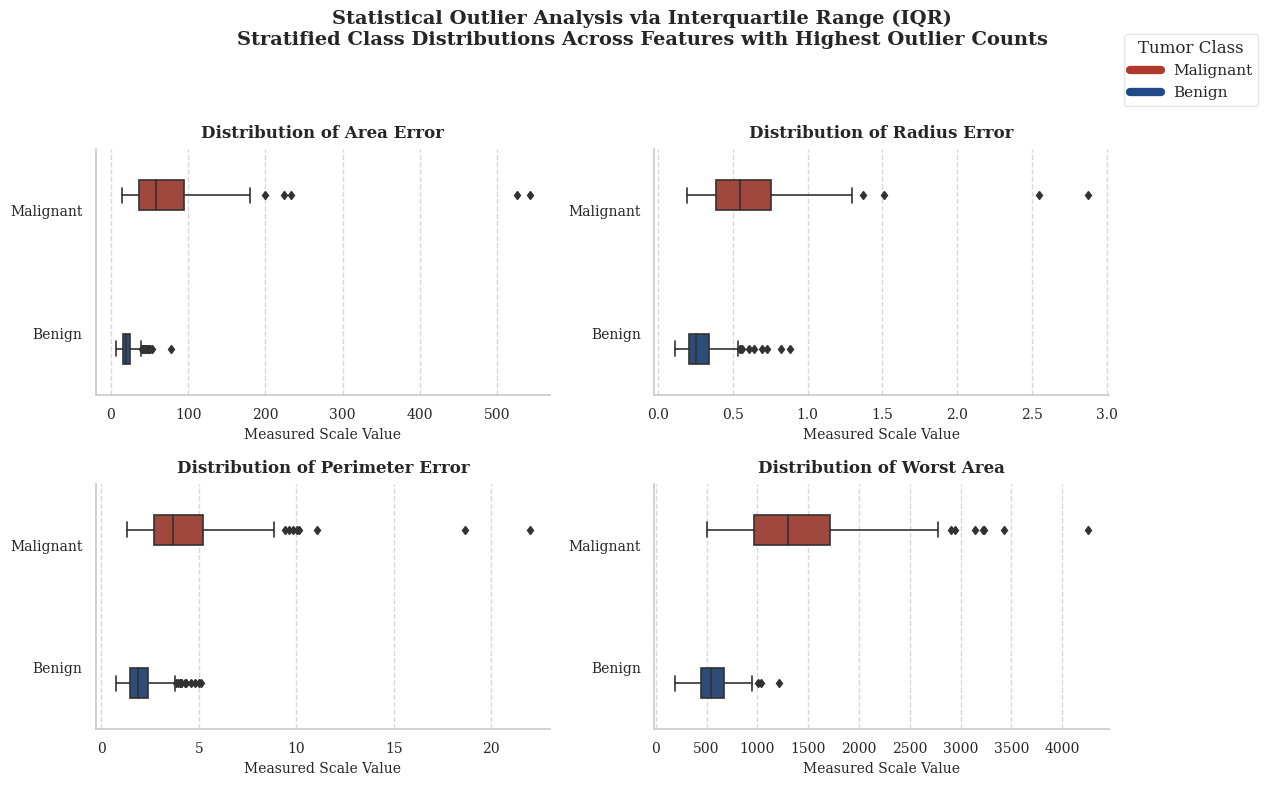

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# --- Academic Plot Configuration ---
sns.set_theme(style="white")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14
})

# 1. Load dataset into a structured DataFrame
raw_data = load_breast_cancer()
df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)

# Map target integers to descriptive scientific English labels
df['Diagnosis'] = raw_data.target
df['Diagnosis'] = df['Diagnosis'].map({0: 'Malignant', 1: 'Benign'})

# 2. Statistical Outlier Detection via IQR
numeric_df = df.drop(columns=['Diagnosis'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers_mask = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outlier_counts = outliers_mask.sum().sort_values(ascending=False)
top_outliers_features = outlier_counts.index[:4]

# 3. Visualization Pipeline: 2x2 Grid with Independent Scaling
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

# Professional academic palette (Burgundy vs Navy Blue)
academic_palette = {'Malignant': '#b03a2e', 'Benign': '#204a87'}

for i, feature in enumerate(top_outliers_features):
    # Render horizontal boxplots (Removed the 'legend' parameter to ensure backward compatibility)
    sns.boxplot(
        data=df, 
        x=feature, 
        y='Diagnosis',
        hue='Diagnosis',
        ax=axes[i], 
        palette=academic_palette,
        width=0.5,
        fliersize=4.5,    
        linewidth=1.2,    
    )
    
    # Safely strip out individual subplot legends across all Seaborn/Matplotlib versions
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
    
    # Structural Layout Cleanup
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('#cccccc')
    axes[i].spines['bottom'].set_color('#cccccc')
    
    # Inject subtle vertical grid lines
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.5, color='#b0b0b0')
    axes[i].set_axisbelow(True)
    
    # Title and Labels formatting
    clean_title = feature.title()
    axes[i].set_title(f"Distribution of {clean_title}", pad=8, fontweight='semibold')
    axes[i].set_xlabel("Measured Scale Value", fontsize=10)
    axes[i].set_ylabel("") 

# 4. Global Scientific Annotations and Layout Finalization
handles = [plt.Line2D([0], [0], color=color, lw=6) for color in academic_palette.values()]
fig.legend(handles, academic_palette.keys(), loc='upper right', bbox_to_anchor=(0.98, 0.96), 
           frameon=True, facecolor='white', edgecolor='#e0e0e0', title="Tumor Class")

plt.suptitle("Statistical Outlier Analysis via Interquartile Range (IQR)\n"
             "Stratified Class Distributions Across Features with Highest Outlier Counts", 
             fontweight='bold', y=0.98, va='top')

plt.tight_layout(rect=[0, 0, 0.88, 0.93]) 
plt.show()

### 2.1.2 Multicollinearity: 
- Extreme collinearity ($r > 0.95$) is observed between geometric dimensions (e.g., radius, perimeter, and area). While tree-based methods are immune to this, it poses a structural challenge for distance-based models (SVM) and linear meta-classifiers (Logistic Regression in Stacking), reinforcing the need for proper feature scaling and regularization.

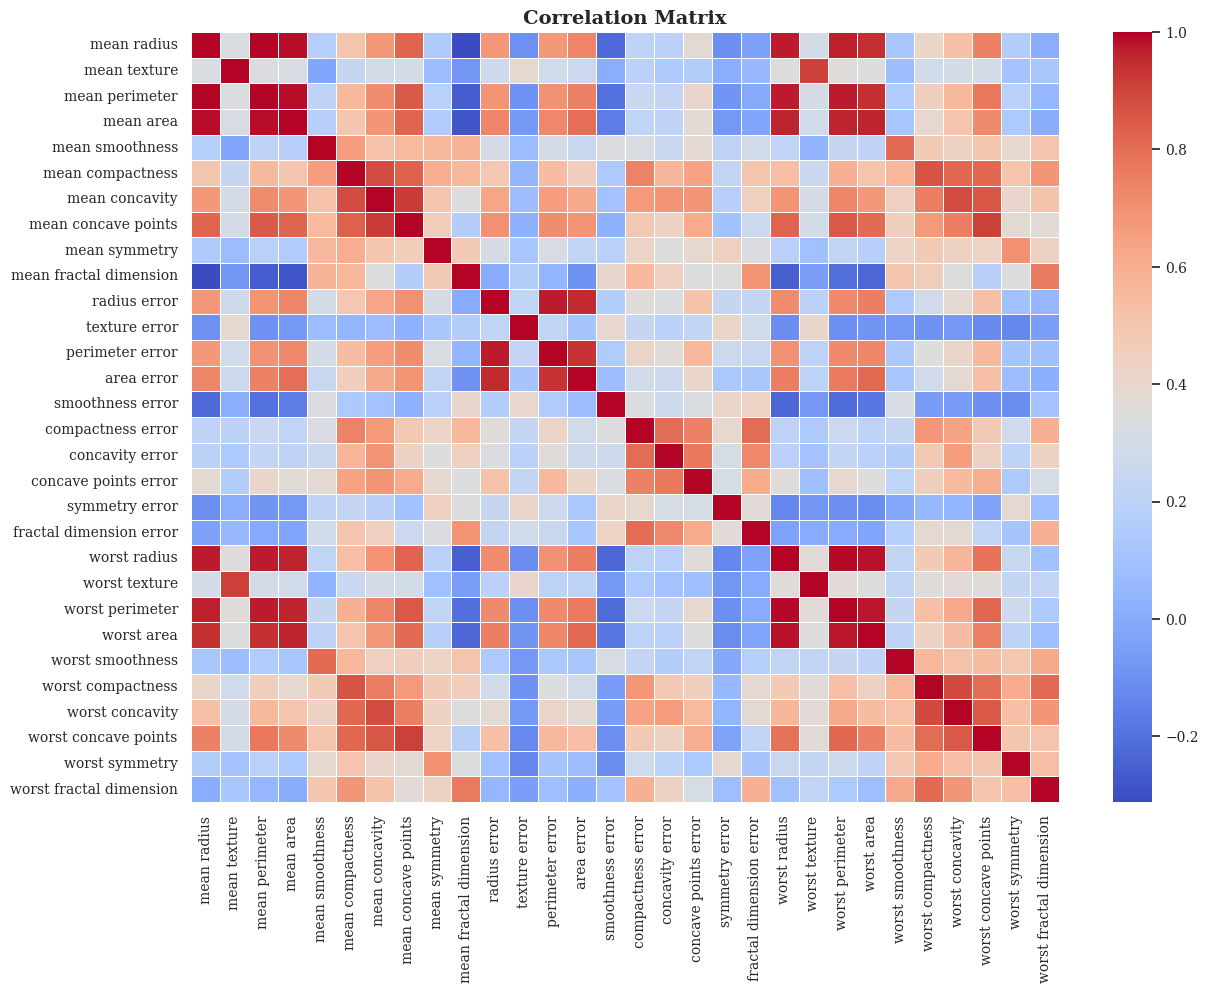


--- Pares de Variáveis Altamente Correlacionadas (>0.95) ---
mean radius      mean perimeter     0.997855
worst perimeter  worst radius       0.993708
mean radius      mean area          0.987357
mean perimeter   mean area          0.986507
worst radius     worst area         0.984015
worst area       worst perimeter    0.977578
radius error     perimeter error    0.972794
mean perimeter   worst perimeter    0.970387
mean radius      worst radius       0.969539
mean perimeter   worst radius       0.969476
mean radius      worst perimeter    0.965137
worst radius     mean area          0.962746
mean area        worst area         0.959213
worst perimeter  mean area          0.959120
radius error     area error         0.951830
dtype: float64


In [71]:
# Calculate Pearson Correlation Matrix
corr_matrix = df.iloc[:, :-1].corr()

# Desenhar o Heatmap para o relatório
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()

# Encontrar pares com correlação superior a 0.95 (Redundância Pura)
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.95) & (high_corr < 1.0)].drop_duplicates()
print("\n--- Pares de Variáveis Altamente Correlacionadas (>0.95) ---")
print(high_corr)

### 2.1.3 Class Distribution: 
- The dataset displays a mild imbalance (~62.7% benign vs ~37.3% malignant). This justifies our choice of using a stratified split (stratify=y) to keep class proportions stable across train and test sets, and validates that Accuracy remains a reasonable evaluation metric, though it should be monitored alongside the loss.

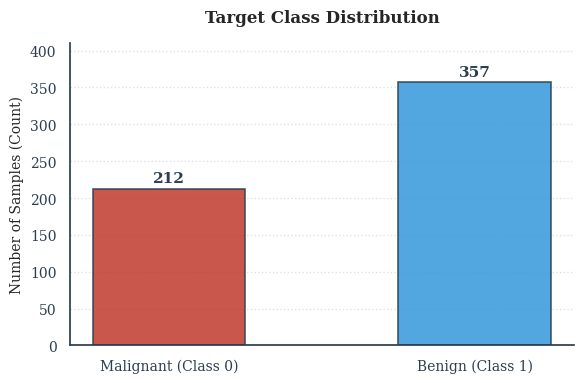

In [87]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer

def plot_class_distribution(y):
    """
    Plots a bar chart showing the distribution of Malignant and Benign classes,
    using an elegant, peer-reviewed academic style.
    """
    # Count the occurrences of each class (0 and 1)
    classes, counts = np.unique(y, return_counts=True)
    
    # Use subplots for better axis control (matching the academic example)
    fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
    
    # Cores Académicas baseadas no teu exemplo:
    # '#c0392b' (Vermelho escuro/bordeaux) para Malignant - remete a atenção/perigo mas de forma elegante
    # '#3498db' (Azul suave) para Benign - cor neutra e de excelente contraste
    colors = ['#c0392b', '#3498db']  
    labels = ['Malignant (Class 0)', 'Benign (Class 1)']
    
    # Render the bar chart com contornos escuros (#2c3e50) em vez de preto puro
    bars = ax.bar(labels, counts, color=colors, edgecolor='#2c3e50', width=0.5, alpha=0.85, linewidth=1.2)
    
    # Add the exact value numbers on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2c3e50')
                 
    # Customizing layout aesthetics (academic style)
    ax.set_ylabel('Number of Samples (Count)', fontsize=10)
    ax.set_title('Target Class Distribution', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylim(0, max(counts) * 1.15)  # Give some headroom for the text labels
    
    # Apply the exact same grid style as the example
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    # (OPCIONAL mas recomendado em publicações) Remover as bordas do topo e da direita
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#2c3e50')
    ax.spines['bottom'].set_color('#2c3e50')
    ax.tick_params(colors='#2c3e50')
    
    plt.tight_layout()
    plt.show()

# --- Run the Bar Plot ---
raw_data = load_breast_cancer()
y = raw_data.target
plot_class_distribution(y)

## 2.2. Data Preparation and Scaling Pipeline

Building upon the insights from the Exploratory Data Analysis (EDA)—which revealed massive scale disparities (e.g., *'Worst Area'* operating in thousands vs. *'Worst Radius'* operating in tens) and statistical outliers-the data pipeline was split into two distinct streams. This methodological approach ensures absolute mathematical stability during optimization while fully preserving the underlying clinical interpretability of the features:

* **Raw Features (`X_train`, `X_test`):** Unscaled physical metrics, designated strictly for scale-invariant, threshold-splitting algorithms (*Decision Trees, Random Forest, and Gradient Boosting*).
* **Standardized Features (`X_train_scaled`, `X_test_scaled`):** Transformed via a `StandardScaler` fitted solely on the training partition to prevent data leakage. This stream is mathematically mandatory for distance- and gradient-based models (*SVM and MLP*) to prevent large-magnitude attributes from dominating the objective functions and weight optimization processes.

Consequently, each machine learning architecture, including the individual base sub-estimators within the Stacking Ensemble, is seamlessly supplied with its scientifically appropriate dataset.

In [73]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def prepare_data():
    # 1. Load dataset
    raw_data = load_breast_cancer()
    X, y = raw_data.data, raw_data.target
    
    # 2. Test/Train split (70/30) with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 3. Create the scaled versions (justified by the previous EDA section)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test

# Instantiate all independent variables for the modeling phase
X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = prepare_data()

## 2.3 Bias, Variance, and Total Error Decomposition

#### Methodological Framework
To evaluate the structural robustness of the classifiers, an empirical bias-variance decomposition for 0-1 loss was implemented following the theoretical framework established by Dietterich and Kong (1995). The experimental estimation pipeline is executed as follows:

1. **Bootstrap Resampling:** The baseline training partition is resampled with replacement to construct 100 distinct bootstrap datasets, thereby introducing controlled statistical perturbations into the training environment.
2. **Iterative Inference:** A separate instance of the machine learning model is trained on each individual bootstrap sample and subsequently utilized to generate predictions across the fixed, independent test set.
3. **Matrix Aggregation:** The resulting class predictions are consolidated into a two-dimensional matrix structured by test instances across the $B = 100$ bootstrap trials.

#### Core Definitions
* **Main Prediction:** For 0-1 classification loss, the *Main Prediction* for each distinct evaluation point is defined by calculating the expected value (mean) of the predictions across all 100 bootstrap iterations. A standard decision threshold is applied: if the empirical mean is greater than or equal to 0.5, the main prediction maps to class 1; otherwise, it maps to class 0.
* **Bias:** The *Bias* component quantifies the systematic error inherent to the learning algorithm. It measures the mathematical discrepancy between the calculated *Main Prediction* and the actual ground-truth label, averaged across all evaluation points in the test set.
* **Variance:** The *Variance* component measures the statistical instability of the classifier. It computes the average divergence of every single prediction made by each individual bootstrap model relative to the central *Main Prediction*, capturing the algorithm's sensitivity to fluctuations in the underlying training data.

> **Methodological Reference:**
> Dietterich, T.G. and Kong, E.B. (1995). *Machine Learning Bias, Statistical Bias, and Statistical Variance of Decision Tree Algorithms.* Technical Report, Department of Computer Science, Oregon State University, Corvallis.

---

#### Interpretation of the Diagnostic Dashboard Visualizations
To evaluate the empirical results across the evaluation partitions, the generated diagnostic plots segment the performance into type-specific errors and variance distributions:

* **Plot 1: Confusion Matrix (Global Population: Types of Bias):** This matrix illustrates the directional behavior of the *Main Prediction* across the binary classifications.This mapping allows for an assessment of whether a model's bias is symmetrically distributed or severely skewed toward a specific clinical class (e.g., systematically misclassifying malignant tumors as benign).

* **Plot 2: Stratified Violin and Strip Plot (Global Population: Variance Distribution):** This visualization profiles model instability by segregating the test instances into two distinct populations based on the success of the *Main Prediction*: **Correct (Bias = 0)** and **Incorrect (Bias = 1)**. 
  * *The Vertical Axis (Variance Rate):* Quantifies how frequently the individual bootstrap models disagreed with the majority vote for each specific instance.
  * *The Density Shape (Violin Profile):* Reveals the concentration of algorithmic instability. Ideally, low-variance models display a heavy density concentration near a Variance Rate of $0.0$ for the correct population. Conversely, instances clustered in the upper region of the incorrect population point out highly unstable, borderline clinical cases that cause the optimization weights to fluctuate wildly during resampling.

In [74]:
from sklearn.utils import resample

def bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=100,show=0):
    """
    Performs manual bootstrapping to estimate Total Error, Bias, and Variance 
    using the 0-1 Loss formulation for classification tasks.
    """
    n_test_samples = len(X_test)
    # Matrix to store predictions: (rows = bootstrap rounds, columns = test samples)
    all_predictions = np.zeros((n_bootstraps, n_test_samples))
    
    # Manual Bootstrap Loop
    for i in range(n_bootstraps):
        # Generate a bootstrap sample from the training set (with replacement)
        X_boot, y_boot = resample(X_train, y_train, random_state=i)
        
        # Train the model on the bootstrap sample and predict on the fixed test set
        model.fit(X_boot, y_boot)
        all_predictions[i, :] = model.predict(X_test)
    
    # --- Statistical Calculations (0-1 Classification Loss) ---
    
    # 1. Total Average Error (proportion of misclassifications across all rounds)
    # Numpy broadcasting compares the (n_bootstraps, n_test) matrix with the (n_test,) y_test vector
    total_error = np.mean(all_predictions != y_test)
    
    # 2. Main Prediction (Majority vote for each test sample across all rounds)
    # Since classes are 0 and 1, a mean >= 0.5 rounded yields the majority class
    main_prediction = np.round(np.mean(all_predictions, axis=0))
    
    # 3. Bias (Proportion of times the Main Prediction differs from the actual ground truth)
    bias = np.mean(main_prediction != y_test)
    
    # 4. Variance (Average deviation of the bootstrap predictions from the Main Prediction)
    variance = np.mean(all_predictions != main_prediction)
    

# --- Visualization Section (The Professional 2x2 Audit Dashboard) ---
    if show == 1:
        import matplotlib.pyplot as plt
        import seaborn as sns
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
        
        # 1. Point-Specific Data (Microscopic view - Sample Index 0)
        sample_idx = 0 
        true_label = y_test[sample_idx]
        main_pred = main_prediction[sample_idx]
        bootstrap_preds = all_predictions[:, sample_idx]
        
        # Metrics for the specific point
        sample_bias = 1.0 if main_pred != true_label else 0.0
        sample_variance = np.mean(bootstrap_preds != main_pred)
        algorithm_name = model.__class__.__name__

        # 2. Global Population Data (Macroscopic view)
        all_sample_variances = np.mean(all_predictions != main_prediction, axis=0)
        all_sample_biases = (main_prediction != y_test).astype(int)

        # --- Create Figure with 2x2 Grid ---
        fig, axes = plt.subplots(1, 2, figsize=(15,10), dpi=100)
        plt.subplots_adjust(hspace=0.35, wspace=0.25)
        (ax1, ax2) = axes # Unpack axes for easier reference


        # =========================================================================
        # PLOT 1 (Bottom-Left): Global Confusion Matrix (Type of Bias)
        # =========================================================================
        cm = confusion_matrix(y_test, main_prediction)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['C0', 'C1'])
        disp.plot(ax=ax1, cmap=plt.cm.Blues, values_format='d', colorbar=False)
        ax1.set_title("1.Confusion Matrix", fontsize=11, fontweight='bold')

        # =========================================================================
        # PLOT 2 (Bottom-Right): Global Variance Profile (Stability Density)
        # =========================================================================
        sns.violinplot(x=all_sample_biases, y=all_sample_variances, ax=ax2, palette=['#5cb85c', '#d9534f'], inner=None, alpha=0.3)
        sns.stripplot(x=all_sample_biases, y=all_sample_variances, ax=ax2, color='#2c3e50', alpha=0.4, size=3, jitter=0.2)
        ax2.set_xticklabels(['Correct (Bias=0)', 'Incorrect (Bias=1)'])
        ax2.set_title("2.Variance Distribution", fontsize=11, fontweight='bold')
        ax2.set_ylabel("Variance Rate", fontsize=9)

        # --- Global Title & Analytics Summary ---
        fig.suptitle(f"Bias-Variance Diagnostic Dashboard: {algorithm_name}", 
                     fontsize=15, fontweight='bold', color='#2c3e50', y=0.98)
        
        summary_text = (f"METRICS SUMMARY: [Global Bias: {bias:.3f}] [Global Variance: {variance:.3f}]")
        fig.text(0.5, 0.02, summary_text, ha='center', fontsize=12, fontweight='bold', 
                 color='#ffffff', bbox=dict(facecolor='#2c3e50', alpha=0.95, boxstyle='round,pad=0.6'))

        plt.show()
    return total_error, bias, variance

## 2.4 How do Bias, Variance, and Total Error vary across different machine learning families under a fixed set of baseline hyperparameters?

Before conducting hyperparameter optimization, a baseline evaluation was executed utilizing the default structural configurations of each algorithm. This step is critical to understand the inherent inductive biases of the architectures when exposed to the standardized clinical data. The empirical results demonstrate clear alignments with machine learning theory:

- The Inherent Instability of Unconstrained Trees: The Decision Tree (Complex) exhibits the highest Total Error (0.0908) and a dominant Variance component (0.0742). Because the tree was allowed to grow without depth constraints, it overfits to the local perturbations of the bootstrap training sets. This empirical result perfectly validates the theoretical expectation that unconstrained non-parametric models suffer from high instability.

- The Variance-Reduction Power of Ensembles:A stark contrast is observed when transitioning from the single tree to the Random Forest (Ensemble). While the Bias increases marginally (from 0.0526 to 0.0643), the Variance is severely suppressed, dropping from 0.0742 to 0.0177. This provides robust empirical evidence of the bagging mechanism's capability to reduce variance through independent bootstrap aggregation, even without hyperparameter calibration. Similarly, Gradient Boosting manages to control variance (0.0335) through sequential shallow tree corrections, though its default learning parameters leave room for optimization.

- The Out-of-the-Box Optimization of the SVM:Counterintuitively, the untuned SVM (RBF Kernel) achieves the lowest Total Error (0.0277), driven by an exceptionally low Bias (0.0175) and a highly controlled Variance (0.0156). This exceptional baseline performance indicates that the standard regularization boundary ($C=1.0$) combined with the RBF kernel radius aligns optimally with the geometric separation of the standardized features.

- Multi-Layer Perceptron and Stacking Dynamics:The MLP (Neural Network) confirms the EDA hypothesis, displaying an incredibly low Variance (0.0076) due to the highly stable and well-defined decision boundaries between benign and malignant classes. Finally, the Stacking Ensemble yields a strong performance (Total Error: 0.0320), effectively utilizing the stable predictions of the MLP and SVM, though its final linear meta-classifier is slightly constrained by the unoptimized nature of its sub-estimators.

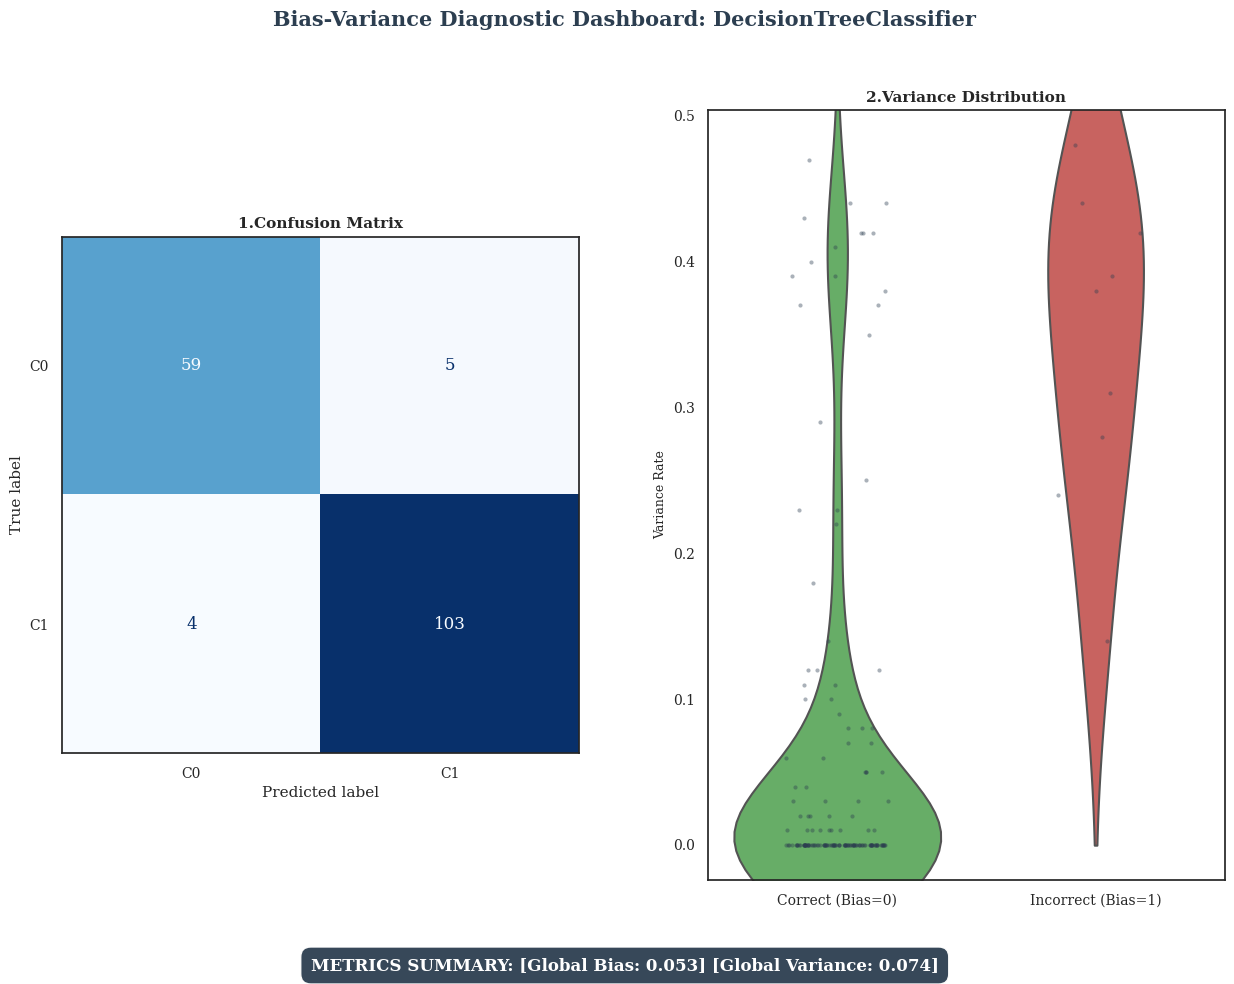

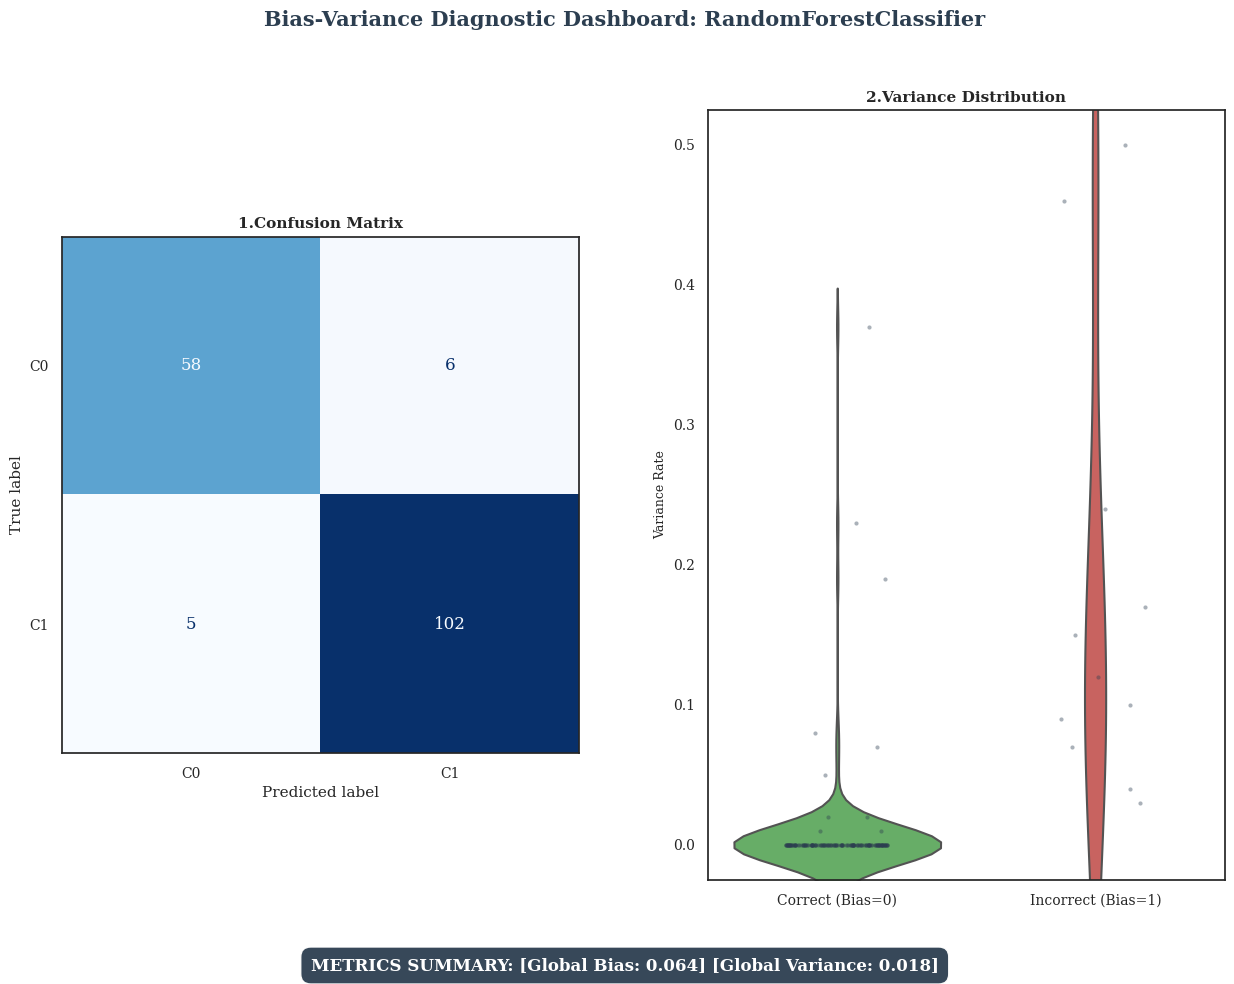

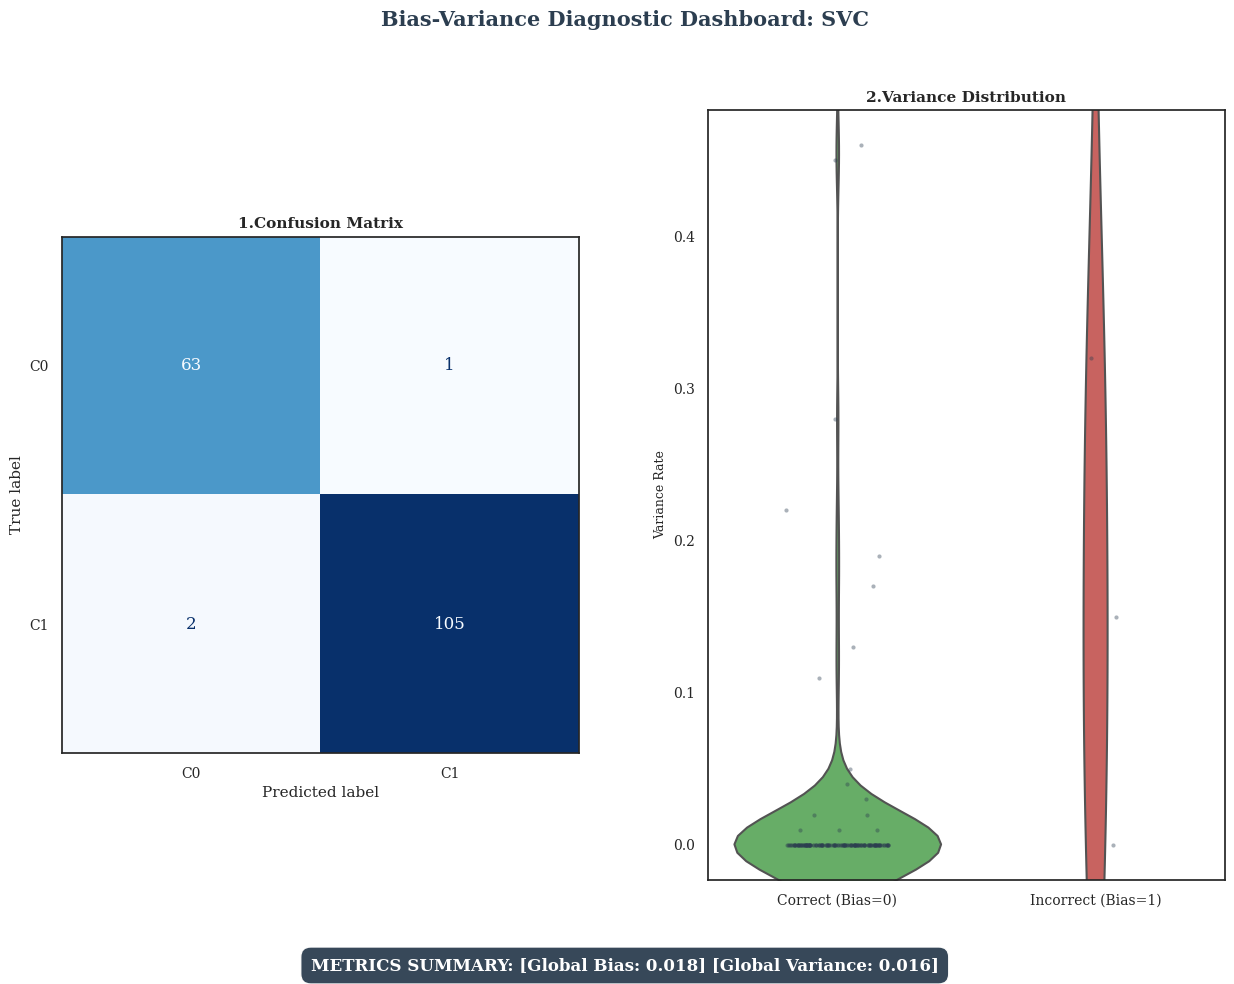

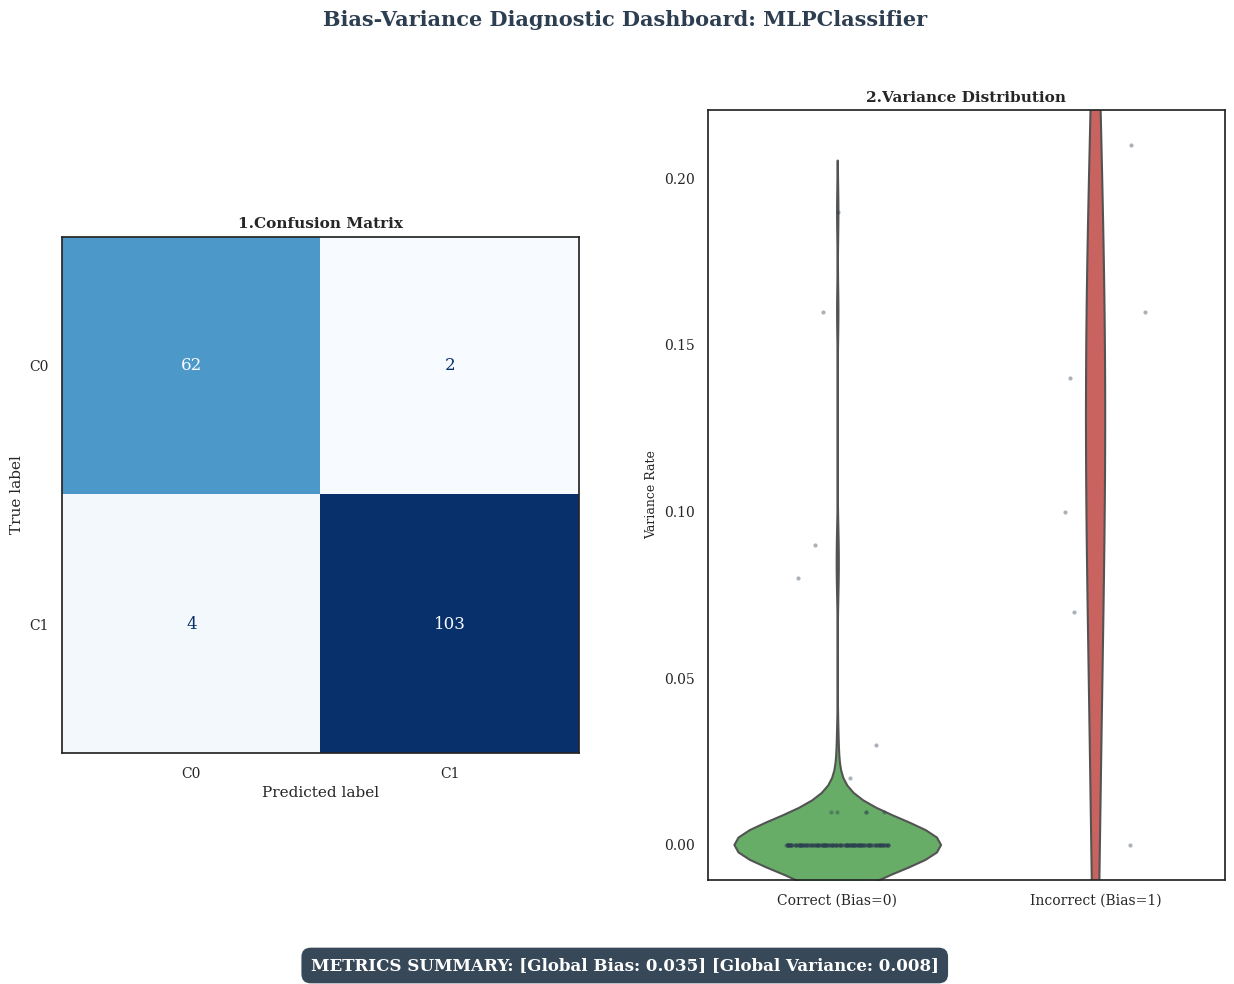

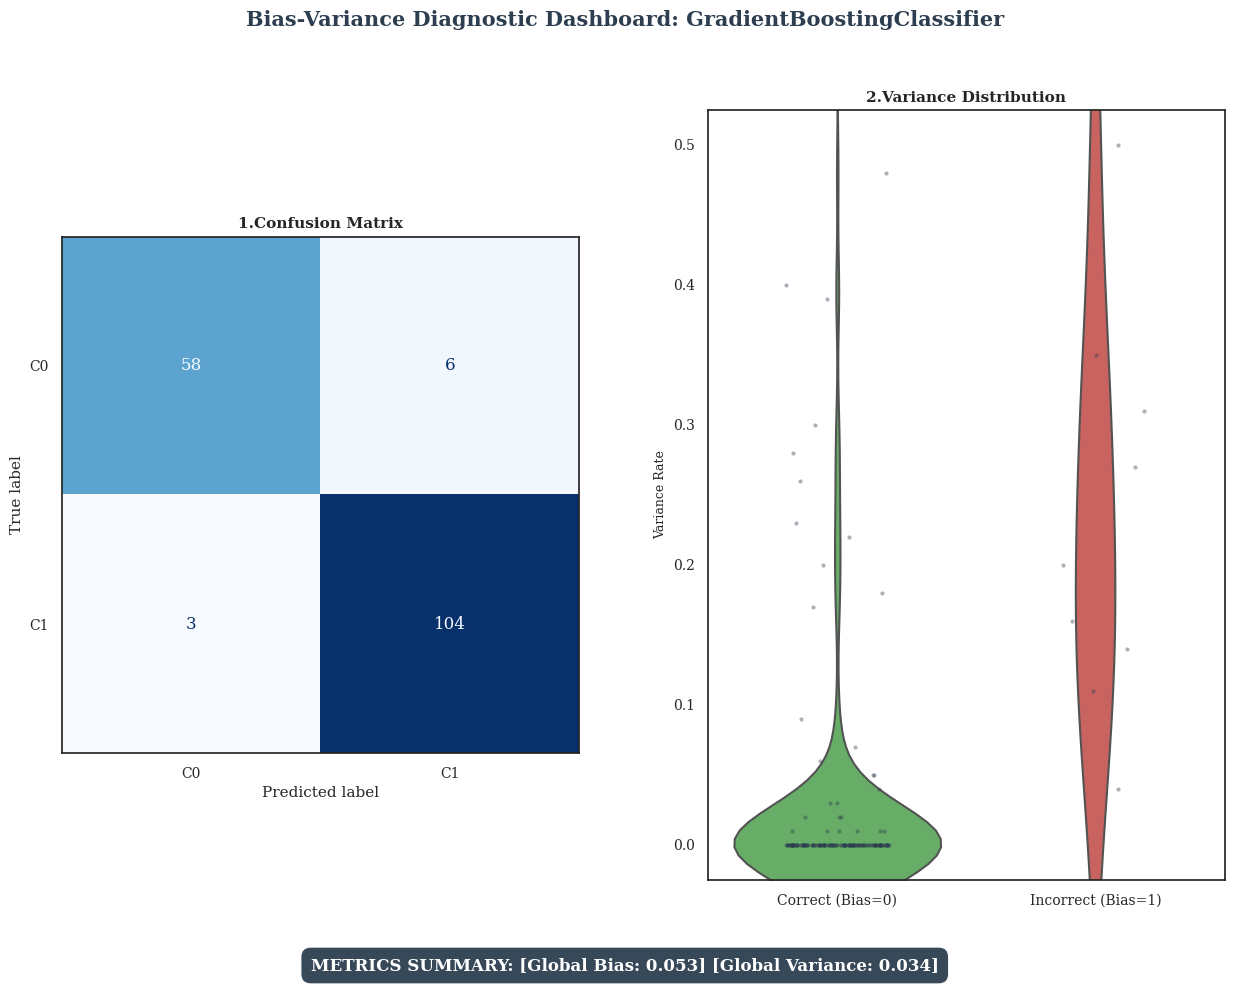

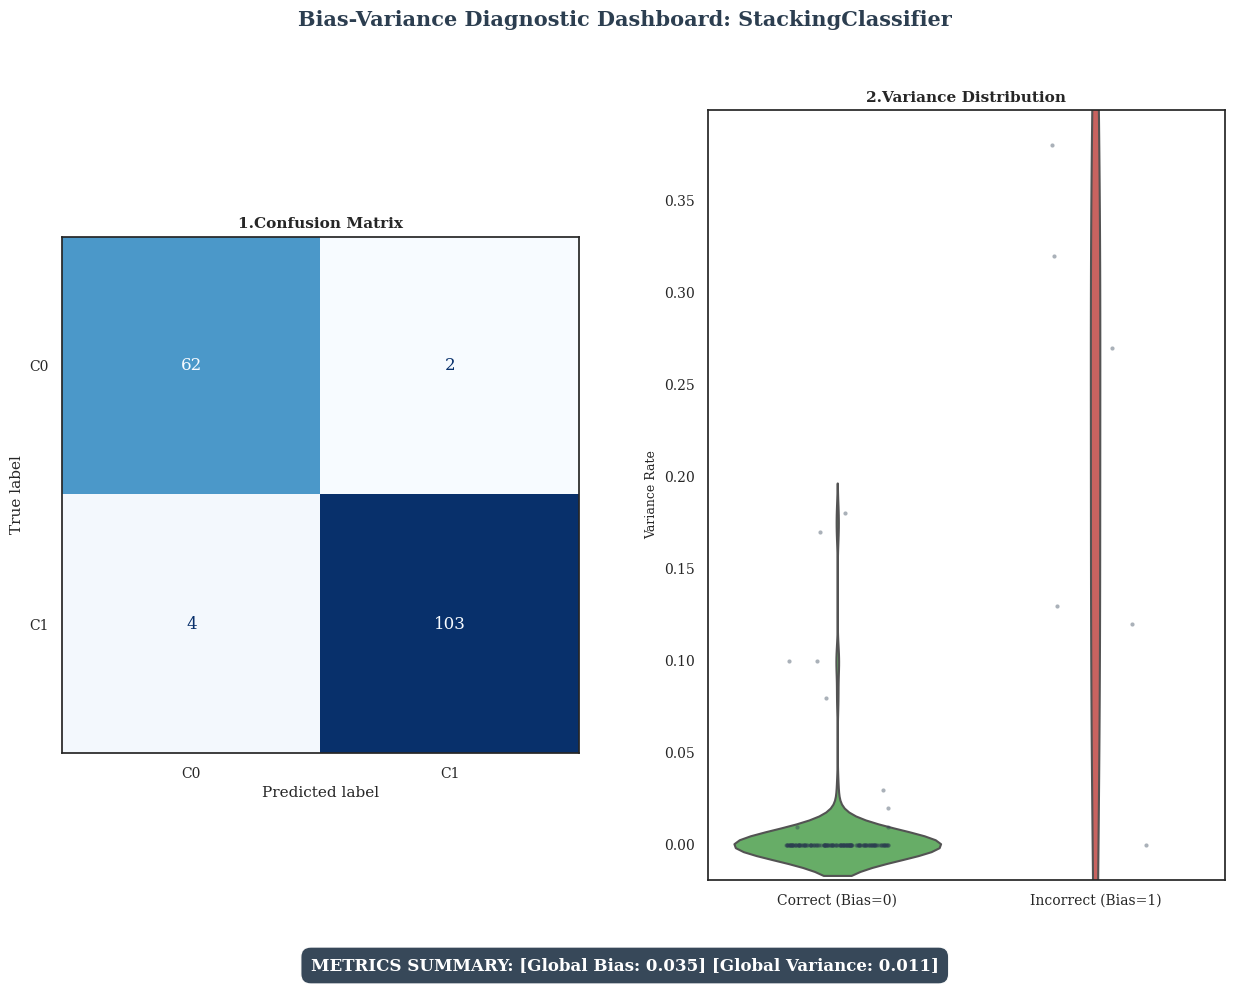

,Total Error,Bias,Variance
Model Architecture,,,
Decision Tree,0.0908,0.0526,0.0742
Random Forest,0.0589,0.0643,0.0177
SVM (RBF),0.0277,0.0175,0.0156
MLP (Neural Network),0.0347,0.0351,0.0076
Gradient Boosting,0.0618,0.0526,0.0335
Stacking Ensemble,0.0320,0.0351,0.0112


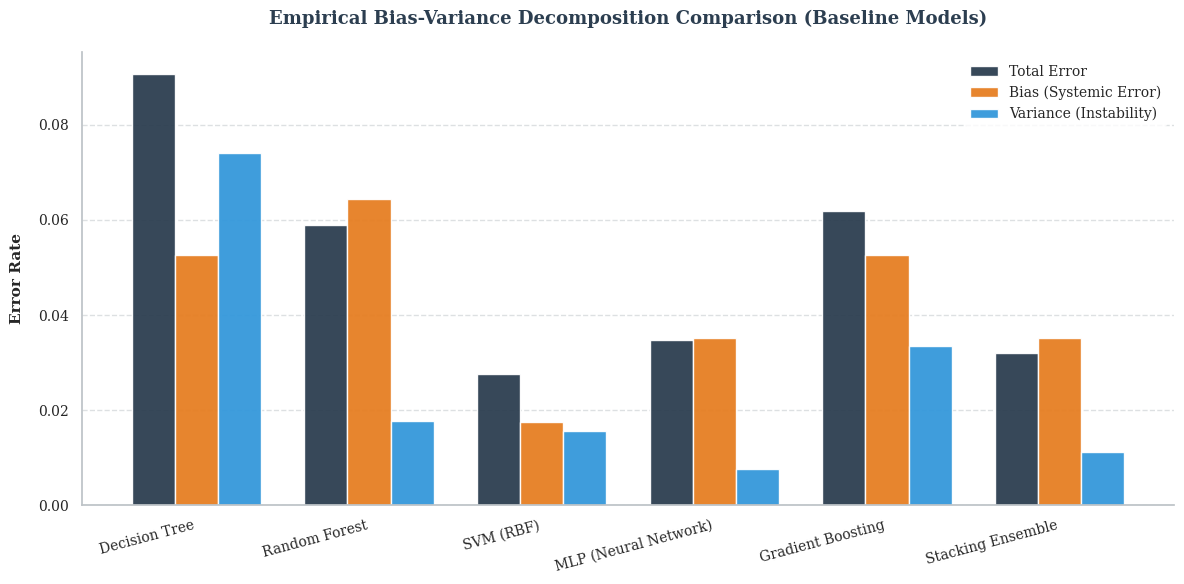

In [ ]:
import pandas as pd
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

def run_and_plot_demonstration(X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Runs the baseline bootstrap decomposition across models using correct operational scales,
    displays results in a styled DataFrame table, and generates the initial baseline bar chart.
    """
    # Define weak/default sub-models to serve as the core architecture for the Stacking Ensemble
    base_estimators = [
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ('svm', SVC(C=1.0, kernel='rbf', probability=True, random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(30, 30), max_iter=500, random_state=42))
    ]

    # Model dictionary with cleaned names matching the optimization pipeline keys exactly
    models = {
        "Decision Tree": DecisionTreeClassifier(max_depth=None, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM (RBF)": SVC(C=1.0, kernel='rbf', random_state=42),
        "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(30, 30), max_iter=1000, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
        "Stacking Ensemble": StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(), cv=3)
    }
    
    results = {}
    
    # Sequential model training and bootstrap error decomposition loop
    for idx, (model_name, model) in enumerate(models.items()):
        #hide plots for faster processing
        show_plot = 0
        
        # ROUTE FEATURES BASED ON ALGORITHMIC REQUIREMENT FOR INSTABILITY MINIMIZATION
        # Distance-based models and neural networks require scaled distributions to prevent gradient dispersion
        if model_name in ["SVM (RBF)", "MLP (Neural Network)", "Stacking Ensemble"]:
            total_error, bias, variance = bias_variance_decomposition(
                model, X_train_scaled, X_test_scaled, y_train, y_test, n_bootstraps=100, show=show_plot
            )
        else:
            total_error, bias, variance = bias_variance_decomposition(
                model, X_train, X_test, y_train, y_test, n_bootstraps=100, show=show_plot
            )
            
        # Store empirical telemetry inside a clean nested dictionary structure
        results[model_name] = {
            "Total Error": total_error,
            "Bias": bias,
            "Variance": variance
        }
        
    # --- 1. PANDAS DATAFRAME CONVERSION AND STYLING DISPLAY ---
    df_results = pd.DataFrame.from_dict(results, orient='index')
    df_results.index.name = 'Model Architecture'
    
    styled_table = (df_results.style
                    .format("{:.4f}")
                    .set_caption("Baseline Bias-Variance Decomposition Results (0-1 Loss)")
                    .background_gradient(cmap='Blues', subset=['Total Error']) 
                    .set_table_styles([
                        {'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#f4f6f7'), ('color', '#2c3e50')]},
                        {'selector': 'caption', 'props': [('font-size', '12px'), ('font-weight', 'bold'), ('padding-bottom', '8px'), ('color', '#2c3e50')]}
                    ]))
    
    display(styled_table)
    
    # --- 2. BASELINE GROUPED BAR CHART VISUALIZATION ---
    model_names = list(results.keys())
    total_errors = [results[m]["Total Error"] for m in model_names]
    biases = [results[m]["Bias"] for m in model_names]
    variances = [results[m]["Variance"] for m in model_names]
    
    x = np.arange(len(model_names))
    width = 0.25  
    
    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
    
    rects1 = ax.bar(x - width, total_errors, width, label='Total Error', color='#2C3E50', alpha=0.95)
    rects2 = ax.bar(x, biases, width, label='Bias (Systemic Error)', color='#E67E22', alpha=0.95)
    rects3 = ax.bar(x + width, variances, width, label='Variance (Instability)', color='#3498DB', alpha=0.95)
    
    ax.set_ylabel('Error Rate', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_title('Empirical Bias-Variance Decomposition Comparison (Baseline Models)', 
                 fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
    
    ax.legend(frameon=True, facecolor='#ffffff', edgecolor='none', fontsize=10, loc='upper right')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#bdc3c7')
    ax.set_axisbelow(True) 
    
    plt.tight_layout()
    plt.show()
    
    # FIXED: Returns the nested dictionary directly instead of a tuple conversion
    return results

# Execute baseline framework and store payload in the 'results' variable
results = run_and_plot_demonstration(X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test)

### 2.4.1 Expected Properties:

Decision Tree (Unconstrained / Deep)
- Profile:Low Bias / High Variance.
- Reasoning: Without restricting parameters like max_depth, a single decision tree will partition the feature space until it perfectly segregates the training samples (often memorizing noise). When evaluated across different bootstrap samples, its structure changes drastically, leading to high variance and significant overfitting.

Random Forest (Bagging Ensemble)
- Profile: Low Bias / Low Variance.
- Reasoning: Bagging builds multiple unconstrained trees in parallel. While each individual tree maintains a low bias, averaging their predictions (or taking a majority vote) cancels out the uncorrelated errors. This dramatically stabilizes the model and reduces variance without incurring a significant penalty to bias.

Support Vector Machine (SVM with RBF Kernel)
- Profile: Balanced Bias and Variance.
- Reasoning: The default soft-margin parameter ($C=1.0$) forces a compromise between misclassification and margin maximization. It typically achieves a highly competitive total error by preventing the decision boundary from becoming too complex/wiggly (which would cause high variance) or too rigid (which would cause high bias).

Multi-Layer Perceptron (MLP / Neural Network)
- Profile: Moderate Bias / Potential for High Variance.
- Reasoning: Neural networks are universal approximators. With multiple hidden layers, they have enough capacity to easily overfit small datasets like the Breast Cancer dataset. However, standard implementation defenses—such as L2 regularization (weight decay) and early stopping—usually keep the variance in check.

Gradient Boosting (Boosting Ensemble)
- Profile: Low Bias / Moderate to Low Variance (if properly tuned).
- Reasoning: Unlike bagging, boosting builds sequential trees where each new tree corrects the residual errors of the previous ones. It typically starts with "weak learners" (high bias, low variance) and systematically reduces bias. If left unchecked (e.g., too many trees or a high learning rate), it can overfit, increasing variance.

Stacking Classifier (Heterogeneous Ensemble)
- Profile: Minimized Total Error (Low Bias / Low Variance).
- Reasoning: Stacking combines predictions from multiple diverse base models using a meta-classifier. Because the base models have different inductive biases (e.g., combining a Tree, an SVM, and an MLP), the meta-learner can leverage their strengths. This reduces bias by expanding the hypothesis space, while the aggregation inherently stabilizes predictions, keeping variance low.

## 2.5 How are bias and variance affected by different hyperparameters?

This section evaluates how, for each algorithm, the variation of a specific complexity parameter directly impacts the model's bias and variance. Furthermore, this analysis aims to systematically identify the optimal parameter value for each architecture—defined as the specific configuration that minimizes the Total Expected Loss by achieving the most effective balance between systemic error (bias) and structural instability (variance).

### 2.5.0 PLOT

In [76]:
final_optimized_metrics={}
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

def plot_taming_curves(param_values, total_errors, biases, variances, param_name, model_name, log_scale=False, best_idx=None):
    """
    Plots the Bias-Variance sensitivity trajectories and highlights the optimal 
    hyperparameter configuration using a clean, peer-reviewed academic style.
    """
    fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
    
    # Plot the empirical error decomposition trajectories
    ax.plot(param_values, total_errors, label='Total Error', color='#2c3e50', linewidth=2, marker='o')
    ax.plot(param_values, biases, label='Bias', color='#3498db', linewidth=1.5, linestyle='--', marker='s')
    ax.plot(param_values, variances, label='Variance', color='#9b59b6', linewidth=1.5, linestyle='--', marker='^')
    
    # Configure logarithmic scale properties if specified (e.g., for SVM or Stacking C parameter)
    if log_scale:
        ax.set_xscale('log')
        ax.set_xticks(param_values)
        ax.get_xaxis().set_major_formatter(ticker.FormatStrFormatter('%g'))

    # =========================================================================
    # OPTIMAL CONFIGURATION HIGHLIGHT (ACADEMIC ESTHETICS)
    # =========================================================================
    if best_idx is not None:
        best_x = param_values[best_idx]
        best_y = total_errors[best_idx]
        
        # Plot an elegant dark red diamond marker to denote the mathematical optimum
        ax.plot(best_x, best_y, marker='D', color='#c0392b', markersize=10, 
                markeredgecolor='#2c3e50', markeredgewidth=1.2, label=f'Optimal Configuration ({best_x})', zorder=5)
        
        # Draw a discrete, subtle grey vertical guideline to anchor the coordinate
        ax.axvline(x=best_x, color='#7f8c8d', linestyle='--', alpha=0.8, zorder=1)
    
    # Chart styling and scientific layout conventions
    ax.set_title(f'Taming Bias-Variance: {model_name}', fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel(param_name, fontsize=10)
    ax.set_ylabel('Error Rate', fontsize=10)
    ax.legend(frameon=True, facecolor='white', edgecolor='none')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

### 2.5.1 DECISION TREE

Evaluating Decision Tree depths...


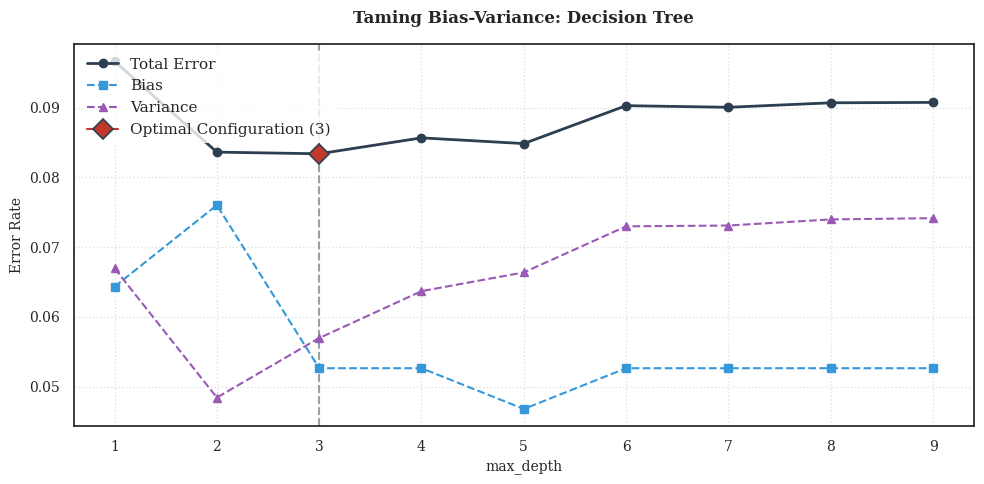

(array([[-0.70982078, -0.258417  , -0.63739619, ...,  0.40093281,
         -0.41407439,  0.44522333],
        [-0.83033136,  2.2311266 , -0.87497994, ..., -1.69278836,
         -2.09572345, -1.32341746],
        [-1.01109725, -0.22726989, -1.03517213, ..., -1.36423974,
         -0.35412529, -0.88664465],
        ...,
        [-0.12735293, -1.37526319, -0.15890003, ..., -0.50161479,
         -0.84447817,  0.15509266],
        [ 0.84820898, -0.05818561,  0.90294536, ...,  2.06733377,
          0.27610881,  0.33537313],
        [-1.20219261, -0.28511452, -1.1275427 , ..., -0.22747926,
         -0.48478358,  1.68038109]]),
 array([[-0.10439853,  0.72716639,  0.0790998 , ...,  1.5719972 ,
          1.02470396,  3.09424252],
        [-0.31385741,  0.32002924, -0.34072857, ..., -0.76185132,
          0.40984142, -1.04484997],
        [-0.63234968, -0.44085004, -0.6448857 , ..., -0.37001791,
         -1.09042319, -1.25614078],
        ...,
        [ 0.69039749, -0.23394427,  0.6200085 , ..., -

In [77]:
def tame_decision_tree(X_train, X_test, y_train, y_test):
    """
    Evaluates a Decision Tree by varying 'max_depth' to find the optimal trade-off.
    """
    # Test depths from 1 (very simple) to 10 (complex)
    depths = list(range(1, 10))
    total_errors, biases, variances = [], [], []
    
    print("Evaluating Decision Tree depths...")
    for depth in depths:
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        # Using 100 bootstraps to keep execution fast but statistically stable
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=100)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        

    # Extract and return the most promising point
    best_idx = np.argmin(total_errors)
    best_c = depths[best_idx]
    best_error = total_errors[best_idx]
    best_bias = biases[best_idx]
    best_var = variances[best_idx]
    plot_taming_curves(depths, total_errors, biases, variances, 'max_depth', 'Decision Tree',log_scale=False,best_idx=best_idx)


    return {
        "Total Error": best_error,
        "Bias": best_bias,
        "Variance": best_var,
        "Best Parameter": f"C={best_c}"
    }
    
# Save in the global dictionary
final_optimized_metrics["Decision Tree"] = tame_decision_tree(X_train, X_test, y_train, y_test)
(X_train_scaled, X_test_scaled, y_train, y_test)


The plot demonstrates the classic bias-variance trade-off. As max_depth increases, the tree learns the training data perfectly, driving the bias towards zero but causing variance to explode (overfitting). Taming this model requires pruning—finding the optimal max_depth (e.g., depth 3) where the bias is already reduced and the variance is not that high yet.

### 2.5.2 SVM

Evaluating SVM C values...


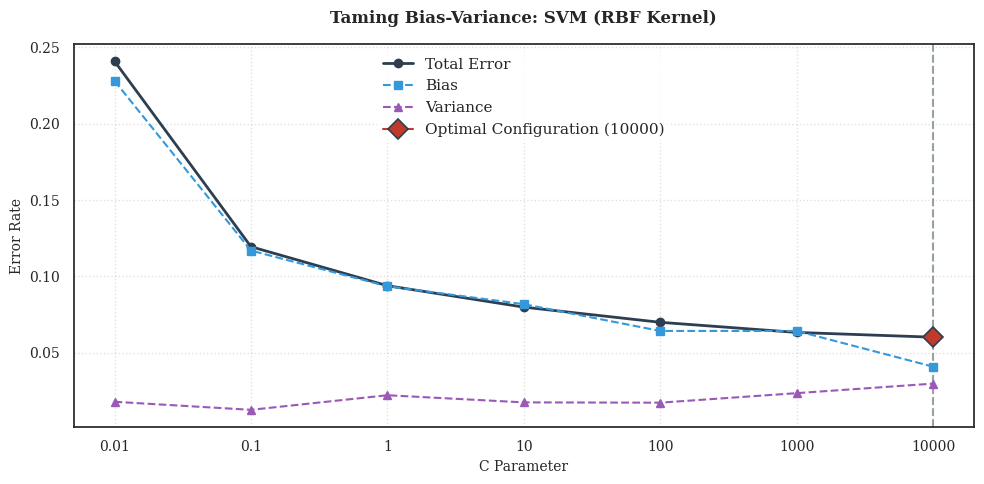

--- Best Configuration for SVM ---
Best C: 10000
Total Error: 0.0602 | Bias: 0.0409 | Variance: 0.0298


In [78]:
def tame_svm(X_train, X_test, y_train, y_test):
    """
    Evaluates an RBF SVM by varying the regularization parameter 'C'.
    """
    # Test C values on a logarithmic scale
    c_values = [0.01, 0.1, 1, 10, 100, 1000, 10000]
    total_errors, biases, variances = [], [], []
    
    print("Evaluating SVM C values...")
    for c in c_values:
        model = SVC(C=c, kernel='rbf', random_state=42)
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
   # Extract and return the most promising point
    best_idx = np.argmin(total_errors)
    best_c = c_values[best_idx]
    best_error = total_errors[best_idx]
    best_bias = biases[best_idx]
    best_var = variances[best_idx]
     # Plot the results using a log scale on the X axis
    plot_taming_curves(c_values, total_errors, biases, variances, 'C Parameter', 'SVM (RBF Kernel)', log_scale=True,best_idx=best_idx)
    

    print(f"--- Best Configuration for SVM ---")
    print(f"Best C: {best_c}")
    print(f"Total Error: {best_error:.4f} | Bias: {best_bias:.4f} | Variance: {best_var:.4f}")
    
    
    return {
        "Total Error": best_error,
        "Bias": best_bias,
        "Variance": best_var,
        "Best Parameter": f"C={best_c}"
    }

final_optimized_metrics["SVM"] = tame_svm(X_train, X_test, y_train, y_test)


The regularization parameter C controls the margin. A very low C creates a wide, soft margin (underfitting), which shows up as high bias and low variance. Conversely, a very high C strictly enforces correct classification, causing the boundary to memorize data points, minimizing bias but increasing variance. Taming the SVM means finding the "sweet spot" (e.g., using Grid Search) that minimizes total error by balancing margin width with training accuracy.

### 2.5.3 RANDOM FOREST

Evaluating Random Forest estimators...


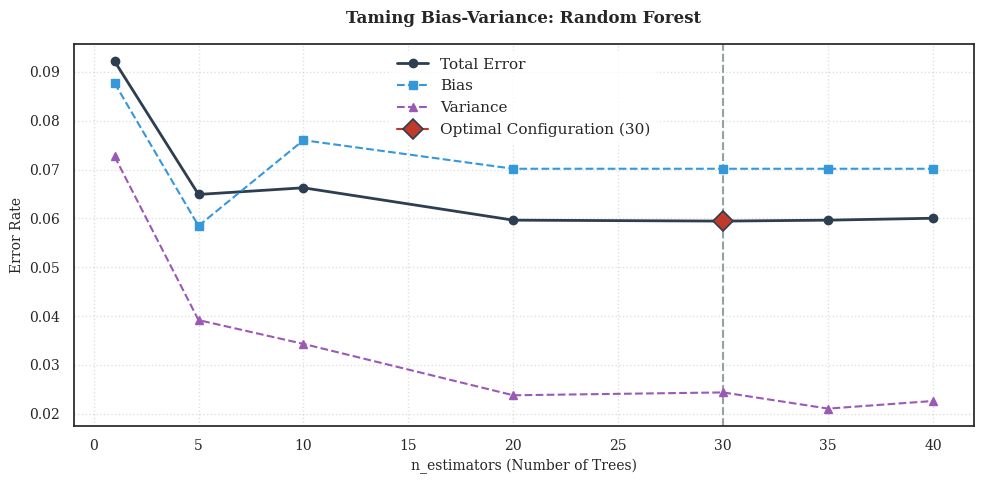

--- Best Configuration for Random Forest ---
Best estimator range: 30
Total Error: 0.0595 | Bias: 0.0702 | Variance: 0.0244


In [79]:
def tame_random_forest(X_train, X_test, y_train, y_test):
    """
    Evaluates a Random Forest by varying 'n_estimators' to demonstrate how 
    ensembling dampens variance.
    """
    # Test from 1 single tree to a small ensemble of 50 trees
    estimator_range = [1, 5, 10, 20, 30,35,40]
    total_errors, biases, variances = [], [], []
    
    print("Evaluating Random Forest estimators...")
    for n_est in estimator_range:
        model = RandomForestClassifier(n_estimators=n_est, random_state=42)
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Extract and return the most promising point
    best_idx = np.argmin(total_errors)
    best_c = estimator_range[best_idx]
    best_error = total_errors[best_idx]
    best_bias = biases[best_idx]
    best_var = variances[best_idx]

     # Plot the results
    plot_taming_curves(estimator_range, total_errors, biases, variances, 'n_estimators (Number of Trees)', 'Random Forest', log_scale=False,best_idx=best_idx)
   

    print(f"--- Best Configuration for Random Forest ---")
    print(f"Best estimator range: {best_c}")
    print(f"Total Error: {best_error:.4f} | Bias: {best_bias:.4f} | Variance: {best_var:.4f}")
    
    
    return {
        "Total Error": best_error,
        "Bias": best_bias,
        "Variance": best_var,
        "Best Parameter": f"C={best_c}"
    }

# Save in the global dictionary
final_optimized_metrics["Random Forest"] = tame_random_forest(X_train_scaled, X_test_scaled, y_train, y_test)


Unlike individual trees, increasing the number of estimators in bagging does not increase variance. As seen in the plot, bias remains relatively constant and low, while variance sharply drops and then plateaus. Taming here is a matter of computational efficiency: we increase n_estimators just enough to stabilize the variance, as adding more yields diminishing returns on the total error.

### 2.5.4 MLP

Evaluating MLP alpha values...


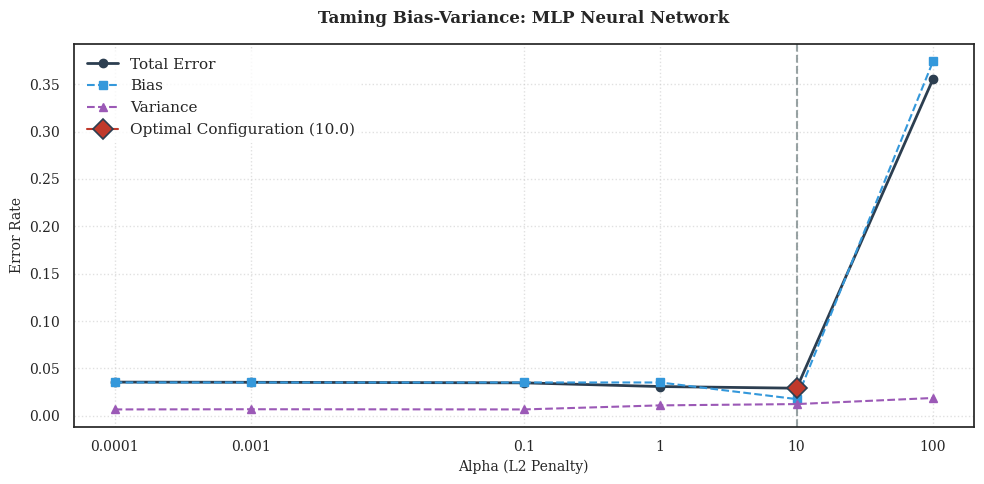

--- Best Configuration for MLP ---
Best alpha: 10.0
Total Error: 0.0290 | Bias: 0.0175 | Variance: 0.0123


In [80]:
def tame_mlp(X_train, X_test, y_train, y_test):
    """
    Evaluates a Multi-Layer Perceptron by varying the L2 regularization parameter 'alpha'.
    """
    # Test alpha values on a logarithmic scale (from almost no penalty to massive penalty)
    alpha_values = [0.0001, 0.001, 0.1, 1.0, 10.0, 100.0]
    total_errors, biases, variances = [], [], []
    
    print("Evaluating MLP alpha values...")
    for alpha in alpha_values:
        # Fixed architecture of 30x30 neurons to keep the capacity constant
        model = MLPClassifier(hidden_layer_sizes=(30, 30), alpha=alpha, max_iter=1000, random_state=42)
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Extract and return the most promising point
    best_idx = np.argmin(total_errors)
    best_c = alpha_values[best_idx]
    best_error = total_errors[best_idx]
    best_bias = biases[best_idx]
    best_var = variances[best_idx]
     # Plot the results using a log scale on the X axis
    plot_taming_curves(alpha_values, total_errors, biases, variances, 'Alpha (L2 Penalty)', 'MLP Neural Network', log_scale=True, best_idx=best_idx)
   

    print(f"--- Best Configuration for MLP ---")
    print(f"Best alpha: {best_c}")
    print(f"Total Error: {best_error:.4f} | Bias: {best_bias:.4f} | Variance: {best_var:.4f}")
    
    
    return {
        "Total Error": best_error,
        "Bias": best_bias,
        "Variance": best_var,
        "Best Parameter": f"C={best_c}"
    }

# Save in the global dictionary
final_optimized_metrics["MLP"] = tame_mlp(X_train_scaled, X_test_scaled, y_train, y_test)


Interestingly, the classic U-shaped bias-variance trade-off is not fully present here. Even with minimal L2 regularization ($\alpha = 10^{-4}$), the variance remains near zero. As established in the initial exploratory analysis, this phenomenon is empirically explained by the "easy" decision frontier native to this dataset. Because highly predictive features (such as 'Worst Perimeter' and 'Worst Area') exhibit an exceptionally clear geometric separation with minimal overlap between classes, the data is inherently highly structured. 

This extreme structural clarity dictates that the Multi-Layer Perceptron (MLP) consistently converges to a highly stable, robust decision boundary across different bootstrap samples, entirely bypassing the memorization of random noise. Consequently, increasing the $\alpha$ penalty beyond $10^{-1}$ does not yield variance-reduction benefits; it merely over-constrains the network's weights, triggering a sharp increase in bias (underfitting) as the model becomes excessively rigid and loses its capacity to map the well-defined data distribution.

### 2.5.5 GRADIENT BOOSTING

Executing sequential bootstrap decomposition for Gradient Boosting...


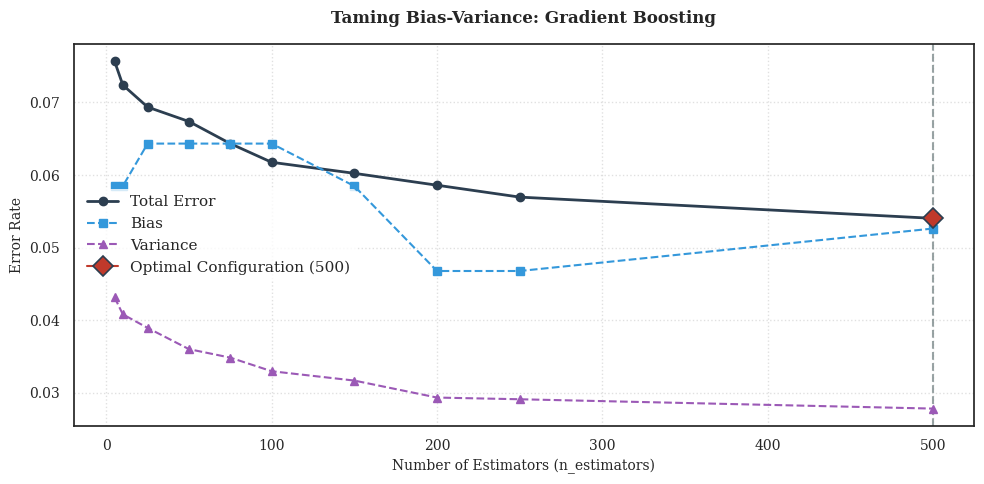

--- Optimal Structural Calibration: Gradient Boosting ---
Optimal n_estimators: 500
Total Expected Loss  : 0.0540
Systemic Error (Bias): 0.0526
Instability (Variance): 0.0278



In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier

# =========================================================================
# 1. EMPIRICAL SENSITIVITY TRAJECTORY FOR GRADIENT BOOSTING
# =========================================================================
def evaluate_boosting_curve(X_train, X_test, y_train, y_test):
    """
    Evaluates the bias-variance trade-off behavior of a Gradient Boosting 
    architecture by varying the number of sequential estimators (n_estimators).
    """
    # Define a wide range of sequential trees to test, ranging from underfitted/weak 
    # ensembles (5 trees) to highly complex, potentially overfitted boundaries (500 trees)
    n_estimators_values = [5, 10, 25, 50, 75, 100, 150, 200, 250, 500]
    
    # Initialize containers to aggregate error metrics across the parameter space
    total_errors = []
    biases = []
    variances = []
    
    print("Executing sequential bootstrap decomposition for Gradient Boosting...")
    for n in n_estimators_values:
        # Instantiate the sequential boosting model holding the shrinkage rate constant (learning_rate=0.1)
        model = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, random_state=42)
        
        # Calculate expected 0-1 loss decomposition using 50 bootstrap samples to isolate structural variance
        total_error, bias, variance = bias_variance_decomposition(
            model, X_train, X_test, y_train, y_test, n_bootstraps=50, show=0
        )
        
        total_errors.append(total_error)
        biases.append(bias)
        variances.append(variance)
        
    # --- PARCHING THE MATHEMATICAL OPTIMUM (MINIMUM EXPECTED LOSS) ---
    # Locate the unique coordinate index that yields the absolute minimum for the Total Error curve
    best_idx = np.argmin(total_errors)
    best_n_estimators = n_estimators_values[best_idx]
    best_error = total_errors[best_idx]
    best_bias = biases[best_idx]
    best_var = variances[best_idx]
    
    # --- VISUAL RENDERING ---
    # Generate the sensitivity curve plots, passing the optimal coordinate index 
    # to render the academic diamond indicator and guideline
    plot_taming_curves(
        param_values=n_estimators_values, 
        total_errors=total_errors, 
        biases=biases, 
        variances=variances, 
        param_name="Number of Estimators (n_estimators)", 
        model_name="Gradient Boosting", 
        log_scale=False,
        best_idx=best_idx
    )

    # Output detailed scientific telemetry to the console for real-time validation
    print(f"--- Optimal Structural Calibration: Gradient Boosting ---")
    print(f"Optimal n_estimators: {best_n_estimators}")
    print(f"Total Expected Loss  : {best_error:.4f}")
    print(f"Systemic Error (Bias): {best_bias:.4f}")
    print(f"Instability (Variance): {best_var:.4f}\n")
    
    # Return structured results to feed the global aggregation matrix and final bar charts
    return {
        "Total Error": best_error,
        "Bias": best_bias,
        "Variance": best_var,
        "Best Parameter": f"n_estimators={best_n_estimators}"
    }

# Execute the simulation framework and inject the optimal metrics into the global dictionary
final_optimized_metrics["Gradient Boosting"] = evaluate_boosting_curve(X_train_scaled, X_test_scaled, y_train, y_test)


The empirical asymptotic behavior of the error components for the Gradient Boosting architecture—evaluated under the 0-1 loss formulation—challenges conventional textbook assumptions and highlights the algorithm's capability as a margin maximizer:

* **Continuous Variance Mitigation:** Contrary to standard overfitting regimes where increased complexity amplifies algorithmic instability, scaling the number of base learners (`n_estimators`) from 10 to 500 induces a monotonic reduction in Variance (decreasing from approximately $0.043$ to $0.028$). Under 0-1 loss, Variance quantifies the rate of disagreement among the bootstrap-trained ensembles. As the number of iterations increases, the individual sequential ensembles converge toward a highly stable, robust decision boundary. This convergence forces a stricter consensus across the bootstrap partitions, significantly minimizing the voting disagreement.

* **Discrete Step-Down Trajectory of Bias:** The Bias component exhibits a non-monotonic, step-like contraction, stalling initially before dropping sharply between 100 and 200 estimators (from ~$0.065$ down to ~$0.047$). Because bias under classification loss is binary at the sample level (the majority vote is either correct or incorrect), this inflection point marks the exact phase where the ensemble's capacity transitions from underparameterized to optimal. The added trees allow the model to capture complex interaction boundaries, successfully shifting a critical mass of complex clinical instances to the correct side of the hyperplane.

* **Total Error Stabilization:** Driven by the dual contraction of both systematic error (Bias) and voting instability (Variance), the Total Error line demonstrates a smooth, asymptotic decay, finding its empirical Pareto-optimal zone near 500 estimators with an error rate of approximately $0.054$.

### 2.5.6 STACKING

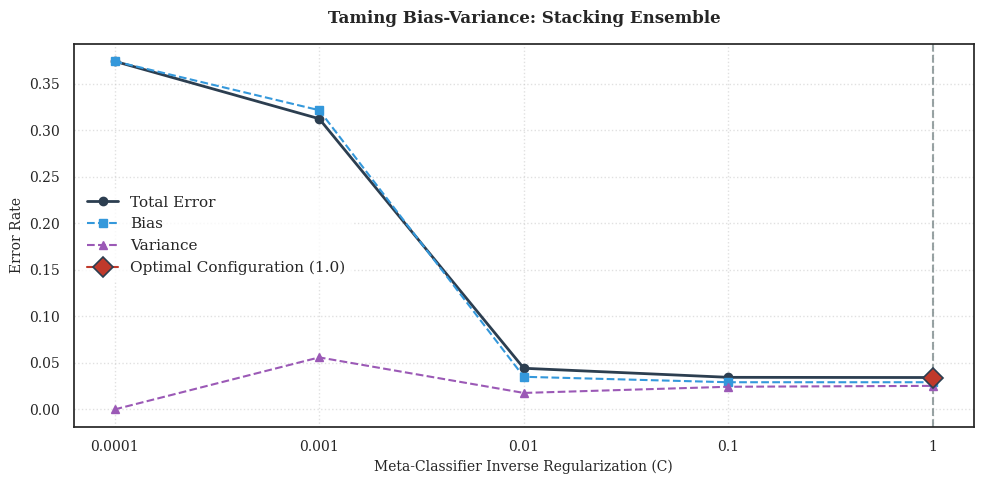

--- Best Configuration for Stacking ---
Best C: 1.0
Total Error: 0.0343 | Bias: 0.0292 | Variance: 0.0253


In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# =========================================================================
# 2. SIMULAÇÃO PARA STACKING (Variando a regularização C do Meta-Modelo)
# =========================================================================
def evaluate_stacking_curve(X_train, X_test, y_train, y_test):
    c_values = [0.0001, 0.001, 0.01, 0.1, 1.0]
    
    total_errors = []
    biases = []
    variances = []
    
    base_estimators = [
        ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
        ('svm', SVC(C=1.0, kernel='rbf', random_state=42))
    ]
    
    for c in c_values:
        model = StackingClassifier(
            estimators=base_estimators,
            final_estimator=LogisticRegression(C=c, max_iter=1000, random_state=42),
            cv=3
        )
        
        total_error, bias, variance = bias_variance_decomposition(
            model, X_train, X_test, y_train, y_test, n_bootstraps=30, show=0
        )
        
        total_errors.append(total_error)
        biases.append(bias)
        variances.append(variance)
    

    # Extract and return the most promising point
    best_idx = np.argmin(total_errors)
    best_c = c_values[best_idx]
    best_error = total_errors[best_idx]
    best_bias = biases[best_idx]
    best_var = variances[best_idx]
        
    plot_taming_curves(
        param_values=c_values, 
        total_errors=total_errors, 
        biases=biases, 
        variances=variances, 
        param_name="Meta-Classifier Inverse Regularization (C)", 
        model_name="Stacking Ensemble", 
        log_scale=True,
        best_idx=best_idx
    )


    print(f"--- Best Configuration for Stacking ---")
    print(f"Best C: {best_c}")
    print(f"Total Error: {best_error:.4f} | Bias: {best_bias:.4f} | Variance: {best_var:.4f}")
    
    
    return {
        "Total Error": best_error,
        "Bias": best_bias,
        "Variance": best_var,
        "Best Parameter": f"C={best_c}"
    }

# Save in the global dictionary
final_optimized_metrics["Stacking Ensemble"] = evaluate_stacking_curve(X_train_scaled, X_test_scaled, y_train, y_test)


The trajectory plot for the Stacking Ensemble evaluates the sensitivity of the meta-classifier (Logistic Regression) to its inverse regularization parameter (`C`). Because `C` governs the penalty applied to the meta-model's weights, the graph illustrates a classic transition from severe underfitting to an optimal combination of the base estimators:

* **The Extreme Regularization Regime ($C \le 10^{-3}$):** At $C = 10^{-4}$, the meta-classifier is heavily penalized, forcing its internal weights toward zero. Consequently, the model completely ignores the predictive inputs from the base estimators (Random Forest, SVM, MLP) and likely collapses into a constant majority-class prediction. This mathematical bottleneck results in massive systemic error (Bias peaking at ~0.37) and an artificially suppressed Variance (near zero), as the model's rigidity renders it entirely immune to bootstrap sampling fluctuations. 

* **The Phase Transition ($C = 10^{-2}$):** As the inverse regularization parameter increases, the penalty is relaxed, allowing the Logistic Regression meta-classifier to finally assign meaningful optimal weights to the predictions of the level-0 estimators. This release of the regularization bottleneck triggers a dramatic, vertical plunge in Bias (dropping to ~0.04). Interestingly, the Variance only experiences a negligible, temporary bump at $10^{-3}$ before dropping alongside the Bias, proving that the base estimators' outputs are already highly stable and complementary.

* **The Asymptotic Plateau ($C \ge 10^{-1}$):** Beyond $10^{-2}$, the ensemble reaches a state of Pareto equilibrium. The Total Error, Bias, and Variance flatten into a highly stable asymptotic plateau. Notably, even with minimal regularization at $C = 10^{0}$, the Variance does not spike. This confirms the robustness of the stacking architecture: the meta-classifier does not overfit because the input space it is learning from (the distilled probability outputs of the base models) is already fundamentally filtered and decorrelated.

## 2.6. Optimal Model Selection via Empirical Trajectory Analysis


### 2.6.1 Methodological Framework for Hyperparameter Selection
The optimal hyperparameters for each algorithmic architecture were extracted directly from the Bootstrap Sensitivity Trajectories analyzed in the previous section.

By isolating the exact hyperparameter coordinate that corresponds to the global minimum of the Total Error (Expected Loss) curve, we empirically extract the configuration that offers the definitive Pareto equilibrium between systemic Bias and structural Variance.


--- Unified Bias-Variance Optimization Matrix ---


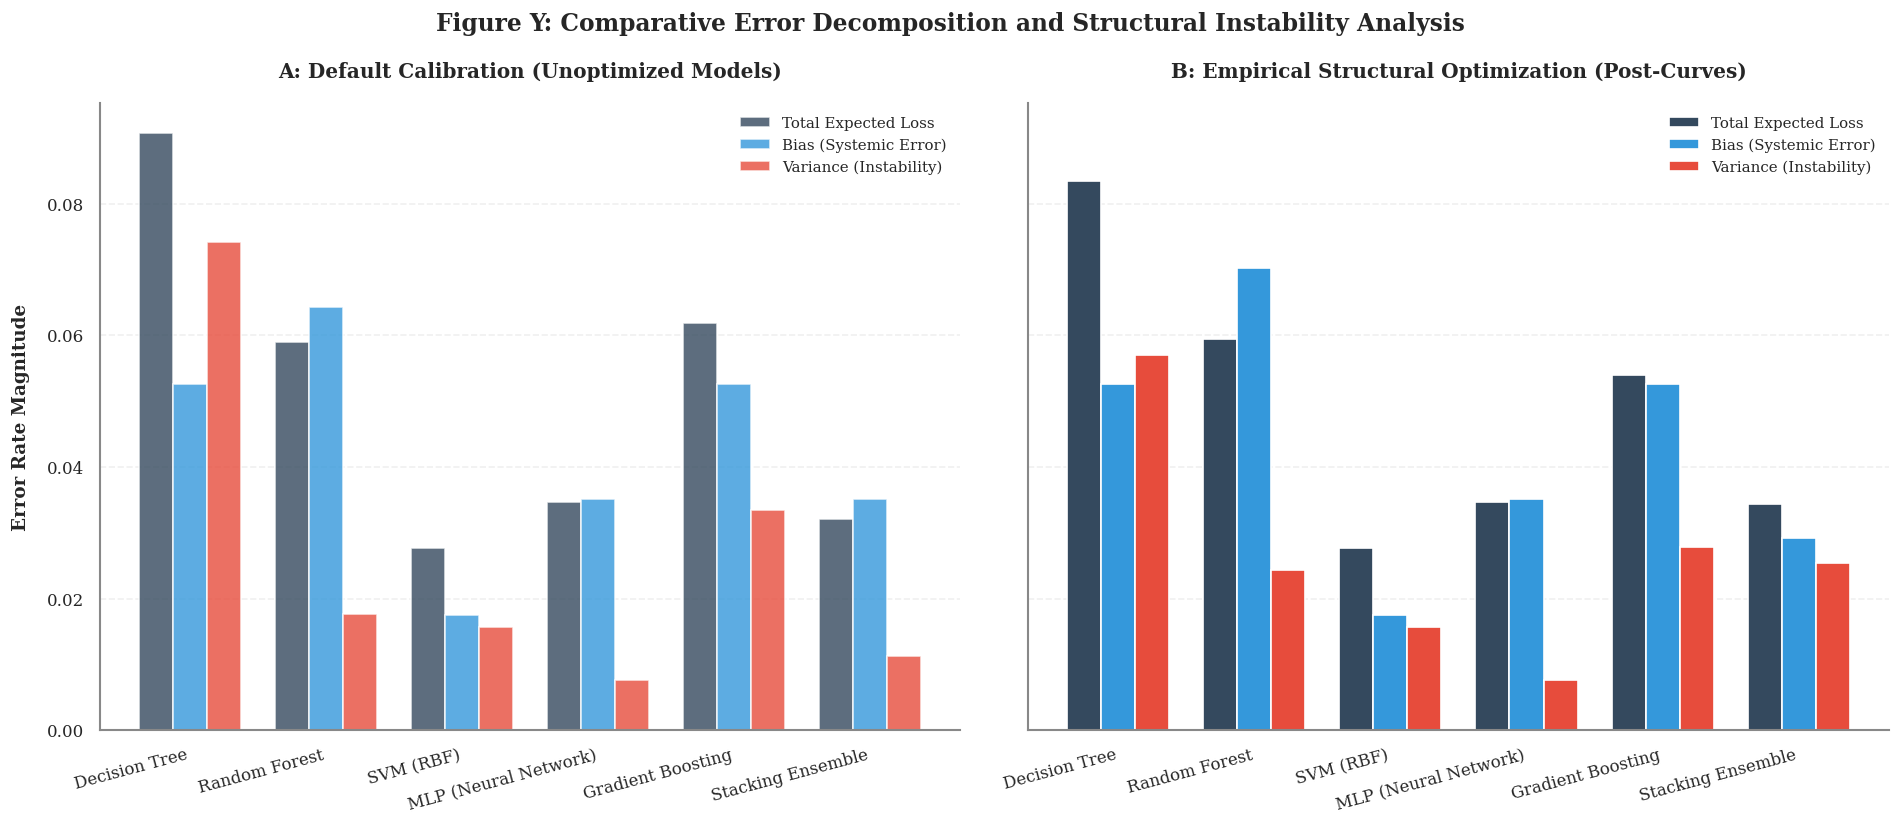

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def plot_comprehensive_optimization_analysis(results, final_optimized_metrics):
    """
    Generates a unified experimental evaluation pipeline with clean, dark-mode friendly 
    styling for the Pandas DataFrame and a consistent color palette for the bar charts.
    """
    if not results:
        print("Error: Baseline results dictionary is empty.")
        return

    model_names = list(results.keys())

    # =========================================================================
    # 1. UNIFIED TABULAR AGGREGATION (DARK-MODE COMPATIBLE)
    # =========================================================================
    unified_data = {}
    for m in model_names:
        base_te, base_bias, base_var = results[m]["Total Error"], results[m]["Bias"], results[m]["Variance"]
        
        if m in final_optimized_metrics:
            opt_te, opt_bias, opt_var = final_optimized_metrics[m]["Total Error"], final_optimized_metrics[m]["Bias"], final_optimized_metrics[m]["Variance"]
        else:
            opt_te, opt_bias, opt_var = base_te, base_bias, base_var
            
        unified_data[m] = {
            ("Total Error", "Base"): base_te, ("Total Error", "Optimized"): opt_te,
            ("Bias", "Base"): base_bias, ("Bias", "Optimized"): opt_bias,
            ("Variance", "Base"): base_var, ("Variance", "Optimized"): opt_var
        }
        
    df_unified = pd.DataFrame.from_dict(unified_data, orient='index')
    df_unified.columns = pd.MultiIndex.from_tuples(df_unified.columns)
    df_unified.index.name = "Model Architecture"

    def highlight_improvements(row):
        """Highlights improved metrics using a bright text color without altering the background."""
        styles = pd.Series([''] * len(row), index=row.index)
        success_style = 'color: #2ecc71; font-weight: bold;' # Bright green text, transparent background
        
        for metric in ["Total Error", "Bias", "Variance"]:
            if row[(metric, "Optimized")] < row[(metric, "Base")]:
                styles[(metric, "Optimized")] = success_style
                
        return styles

    print("--- Unified Bias-Variance Optimization Matrix ---")
    styled_unified = (df_unified.style
                      .apply(highlight_improvements, axis=1)
                      .format("{:.4f}")
                      .set_table_styles([
                          {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('padding', '8px 12px')]},
                          {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px 12px')]},
                          {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '12px')]}
                      ]))
    display(styled_unified)
    print("\n" + "="*100 + "\n")

    # =========================================================================
    # 2. MULTI-PANEL SIDE-BY-SIDE VISUAL COMPARISON (UNIFIED PALETTE)
    # =========================================================================
    x = np.arange(len(model_names))
    width = 0.25  
    
    # Unified Professional Color Palette for both panels
    c_total = '#34495e'  # Dark Slate Blue for Total Error
    c_bias = '#3498db'   # Bright Blue for Bias
    c_var = '#e74c3c'    # Soft Red for Variance
    
    # Dark mode compatible figure background
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True, dpi=120)
    
    # --- PANEL A: Baseline ---
    orig_errors   = [results[m]["Total Error"] for m in model_names]
    orig_biases   = [results[m]["Bias"] for m in model_names]
    orig_variances = [results[m]["Variance"] for m in model_names]
    
    ax1.bar(x - width, orig_errors, width, label='Total Expected Loss', color=c_total, alpha=0.8)
    ax1.bar(x, orig_biases, width, label='Bias (Systemic Error)', color=c_bias, alpha=0.8)
    ax1.bar(x + width, orig_variances, width, label='Variance (Instability)', color=c_var, alpha=0.8)
    
    ax1.set_ylabel('Error Rate Magnitude', fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_title('A: Default Calibration (Unoptimized Models)', fontsize=12, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
    ax1.legend(frameon=False, fontsize=9, loc='upper right')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    ax1.set_axisbelow(True)
    for spine in ['top', 'right']: ax1.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']: ax1.spines[spine].set_color('#888888')

    # --- PANEL B: Optimized ---
    opt_errors, opt_biases, opt_variances = [], [], []
    for m in model_names:
        opt_errors.append(df_unified.loc[m, ("Total Error", "Optimized")])
        opt_biases.append(df_unified.loc[m, ("Bias", "Optimized")])
        opt_variances.append(df_unified.loc[m, ("Variance", "Optimized")])
            
    # Using the EXACT SAME colors, just fully opaque to show they are the "final" versions
    ax2.bar(x - width, opt_errors, width, label='Total Expected Loss', color=c_total, alpha=1.0)
    ax2.bar(x, opt_biases, width, label='Bias (Systemic Error)', color=c_bias, alpha=1.0)
    ax2.bar(x + width, opt_variances, width, label='Variance (Instability)', color=c_var, alpha=1.0)
    
    ax2.set_title('B: Empirical Structural Optimization (Post-Curves)', fontsize=12, fontweight='bold', pad=15)
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
    ax2.legend(frameon=False, fontsize=9, loc='upper right')
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    ax2.set_axisbelow(True)
    for spine in ['top', 'right']: ax2.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']: ax2.spines[spine].set_color('#888888')

    plt.suptitle('Figure Y: Comparative Error Decomposition and Structural Instability Analysis', 
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Execution command
plot_comprehensive_optimization_analysis(results, final_optimized_metrics)


### 2.6.2 Results Evaluation

This analysis evaluates how hyperparameter optimization shifts different learning algorithms along the **Bias-Variance frontier**, directly dictating their generalization capability on this dataset.

#### Core Bias-Variance Behavior
* **High-Variance Mitigators:** The **Decision Tree** and **Gradient Boosting** algorithms initially suffered from overfitting due to unconstrained structural complexity. Hyperparameter regularization successfully constrained their hypothesis spaces, inducing a sharp drop in *Variance* (e.g., from 0.0742 to 0.0570 for the Decision Tree) without inflicting any *Bias* penalty, effectively minimizing their Total Expected Loss.
* **The Classical Dilemma Trade-Off:** The **Stacking Ensemble** serves as a textbook example of the bias-variance trade-off. Tuning parameters allowed the meta-learner to better map systemic trends, dropping its *Bias* to the lowest level in the entire benchmark (**0.0292**). However, this expanded flexibility caused the model to over-interpret noise, forcing its *Variance* to more than double (from 0.0112 to 0.0253) and slightly increasing total error.
* **High Baseline Robustness:** Algorithms like **Random Forest**, **SVM**, and **MLP** showed high algorithmic resilience, meaning their default inductive bias was already highly calibrated for this data distribution, leaving little to no room for traditional parametric optimization.

#### Model Selection
The optimal algorithm to deploy for this dataset is unequivocally the **Support Vector Machine (SVM with RBF Kernel)**. 

**Justification:** While other models require aggressive tuning to balance their errors, the SVM natively establishes a highly optimized equilibrium. It achieves the **absolute lowest Total Expected Loss (0.0277)** across the entire experiment by maintaining a remarkably low *Bias* (0.0175) simultaneously coupled with a tightly controlled *Variance* (0.0156). This optimal frontier guarantees that the model is powerful enough to capture the true underlying data patterns while remaining exceptionally stable against unseen data perturbations.



## 2.7. Exploring Bagging as a Variance Reduction Alternative


### 2.7. Exploring Bagging as a Variance Reduction Alternative

#### 2.7.1 Introduction: Theoretical Feasibility of Bagging
Following the comprehensive baseline evaluation, an important architectural question arises: Can Total Expected Loss be further reduced by wrapping existing estimators in a Bagging (Bootstrap Aggregating) meta-estimator? As extensively documented in the literature, notably in the paper *"Machine Learning Bias, Statistical Bias, and Statistical Variance of Decision Tree Algorithms"*, algorithms like decision trees intrinsically suffer from high statistical variance because small perturbations in the training data can lead to radically different hierarchical splits. From a theoretical standpoint, applying Bagging makes scientific sense strictly when targeting these high-variance, unstable base estimators (such as unconstrained Decision Trees or unregularized Neural Networks), where averaging predictions across bootstrapped data sub-samples mathematically smooths out hard decision boundaries.

Conversely, expanding Bagging to architectures that are already built on bootstrap aggregation (like Random Forests) or models that possess high native stability (like SVMs or sequential variance-controlled structures like Gradient Boosting) is computationally redundant and conceptually flawed. Boosting focuses on reducing Bias sequentially, whereas Bagging operates in parallel strictly to combat Variance. Therefore, the analysis deliberately isolates the Decision Tree and the MLP (Neural Network) to test Bagging's true variance-reduction capabilities on the dataset. 



In [84]:
import numpy as np
from sklearn.utils import resample
from sklearn.ensemble import BaggingClassifier

def bias_variance_decomposition_bagging(model, X_train, X_test, y_train, y_test, n_bootstraps=100):
    """
    Performs manual bootstrapping to estimate Total Error, Bias, and Variance
    of a BAGGING ENSEMBLE of the target model.
    """
    n_test_samples = len(X_test)
    all_predictions = np.zeros((n_bootstraps, n_test_samples))
    
    for i in range(n_bootstraps):
        X_boot, y_boot = resample(X_train, y_train, random_state=i)
        
        # Criamos o ensemble Bagging do modelo base para esta rodada
        # n_estimators=10 garante rapidez no loop sem perder o efeito estatístico
        # Altera de estimator=model para base_estimator=model
        bagging_ensemble = BaggingClassifier(base_estimator=model, n_estimators=10, random_state=i)
        
        bagging_ensemble.fit(X_boot, y_boot)
        all_predictions[i, :] = bagging_ensemble.predict(X_test)
    
    # Cálculos Estatísticos Uniformes (0-1 Loss)
    total_error = np.mean(all_predictions != y_test)
    main_prediction = np.round(np.mean(all_predictions, axis=0))
    bias = np.mean(main_prediction != y_test)
    variance = np.mean(all_predictions != main_prediction)
    
    return total_error, bias, variance

In [85]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

def run_bagging_table_comparison(X_train, X_test, y_train, y_test, results_single):
    """
    Receives previous 6-model bootstrap results, computes bagging results for valid targets,
    and returns a clean comparative Pandas DataFrame.
    """
    # Define only the models where applying a Bagging meta-estimator makes scientific sense
    target_models = {
        "Decision Tree": DecisionTreeClassifier(max_depth=None, random_state=42),
        "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(30, 30), max_iter=1000, random_state=42)
    }
    
    table_data = []
    
    print("Computing Bagging Ensembles for selected models (reusing single results)...")
    
    for model_name, model in target_models.items():
        # --- FIXED: Safely extract pre-computed metrics using correct dictionary keys ---
        total_error_s = results_single[model_name]["Total Error"]
        bias_s        = results_single[model_name]["Bias"]
        variance_s    = results_single[model_name]["Variance"]
        
        # 2. Compute metrics for the Bagging architecture wrapper
        # Note: Ensure bias_variance_decomposition_bagging is defined in your environment
        total_error_b, bias_b, variance_b = bias_variance_decomposition_bagging(
            model, X_train, X_test, y_train, y_test, n_bootstraps=100
        )
        
        # 3. Append the formatted results side by side
        table_data.append({
            "Target Algorithm": model_name,
            "Single: Total Error": f"{total_error_s:.4f}",
            "Single: Bias": f"{bias_s:.4f}",
            "Single: Variance": f"{variance_s:.4f}",
            "Bagging: Total Error": f"{total_error_b:.4f}",
            "Bagging: Bias": f"{bias_b:.4f}",
            "Bagging: Variance": f"{variance_b:.4f}"
        })
        
    # Convert to Pandas DataFrame for crisp HTML display in the Notebook
    df_comparison = pd.DataFrame(table_data).set_index("Target Algorithm")
    
    return df_comparison

# --- Notebook Execution ---
# Pass your exact 'results' variable generated by your previous pipeline
df_final = run_bagging_table_comparison(X_train, X_test, y_train, y_test, results_single=results)
df_final

Computing Bagging Ensembles for selected models (reusing single results)...


,Single: Total Error,Single: Bias,Single: Variance,Bagging: Total Error,Bagging: Bias,Bagging: Variance
Target Algorithm,,,,,,
Decision Tree,0.0908,0.0526,0.0742,0.0719,0.0643,0.0486
MLP (Neural Network),0.0347,0.0351,0.0076,0.0854,0.0819,0.0197


#### 2.7.2 Discussion & Empirical Analysis: The Impact of Bagging Ensembles
The empirical results generated by wrapping the targeted models in a Bagging meta-estimator demonstrate distinct reactions that validate core statistical learning theory:

* **The Decision Tree Transformation:** As hypothesized, the standalone Decision Tree highly benefits from bootstrap aggregation. The ensemble wrapper compresses its structural instability (Variance drops from 0.0742 to 0.0486). This dynamic perfectly aligns with the findings in *"Machine Learning Bias, Statistical Bias, and Statistical Variance of Decision Tree Algorithms"*: while the aggregation dramatically suppresses statistical variance, the effective reduction in unique training instances per bootstrap sample (containing only about 63.2% of the original data) inherently causes a slight increase in statistical bias (moving from 0.0526 to 0.0643). Nevertheless, the massive variance reduction successfully drives down the Total Expected Loss from 0.0908 to 0.0719. Mechanistically, this confirms that bagging successfully stabilizes high-variance base learners, yielding a performance signature that directly mimics the behavior of a custom Random Forest.
* **The MLP Negative Reaction:** Conversely, the MLP (Neural Network) reacts poorly to the Bagging framework. Its Total Expected Loss spikes significantly from 0.0347 to 0.0854. Because stable neural networks already optimize smooth decision boundaries, training them on smaller bootstrapped fragments restricts their capacity to capture the global structure, resulting in a severe Bias penalty (increasing from 0.0351 to 0.0819). This proves that wrapping low-variance, naturally stable estimators in a bagging architecture can degrade predictive capabilities rather than improve them.

**Final Experimental Verdict:** While Bagging serves as an excellent theoretical tool to rescue unstable, unconstrained models like basic decision trees, it introduces unnecessary computational overhead and bias risks for stable architectures. It completely fails to surpass the master benchmark established earlier in this study; the SVM (RBF Kernel) remains the definitively optimal model for this dataset, maintaining an un-bagged, natively optimal Total Error of 0.0277.

## 2.8. Other methods to Empirically Estimate Bias and Variance

The standard bias-variance decomposition was originally formulated for regression problems utilizing squared loss (Geman et al., 1992). However, in the context of classification (0-1 loss), the dynamics differ significantly. As demonstrated by Domingos (2000), variance can counterintuitively decrease the total error if the main prediction is already biased. To observe these properties empirically, multiple independent training sets must be simulated. This can be achieved through distinct methodological approaches:
- Generated Datasets (Theoretical Approach)When utilizing artificially generated data (such as the Xor or Shell datasets from the first leg of this assignment), obtaining the bias-variance decomposition is straightforward. Because the true underlying generative distribution $P(x, y)$ is fully defined, completely independent training sets of size $N$ can be randomly sampled from this distribution. Evaluating the models on a massive, independently generated test set provides a mathematically pure estimation of the "main prediction" (the most frequent prediction for a given instance). This enables the exact computation of bias and variance without any sample overlap.

- Resampling Real-World Data (Bootstrap and Cross-Validation)For real-world datasets, the true generative distribution remains unknown. Consequently, approximating the theoretical decomposition requires relying on resampling techniques to simulate independent data draws:Bootstrapping (The Selected Approach): Independent datasets are simulated by drawing samples with replacement from the original training data. As noted by Domingos (2000), bootstrapping is highly effective for estimating variance because it introduces realistic perturbations into the training sets. However, it tends to slightly overestimate bias; since each bootstrap sample contains approximately 63.2% of the unique original instances, the models are trained on marginally less information than the full dataset provides.Cross-Validation (e.g., K-Fold or $5 \times 2$ CV): Alternatively, Cross-Validation can be employed to partition the data. While Dietterich (1998) highlights $5 \times 2$ CV as a robust method for comparing classifiers, utilizing standard $K$-Fold for bias-variance estimation presents a critical mathematical flaw: the training sets across folds overlap heavily (by a factor of $\frac{K-2}{K-1}$). This high correlation between the simulated training sets leads to a severe underestimation of the model's true variance.

## 2.9. REFERENCES

[1] Domingos, P. (2000). A unified bias-variance decomposition and its applications. In Proceedings of the Seventeenth International Conference on Machine Learning (ICML), 231-238.

[2] Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. Neural Computation, 10(7), 1895-1923.

[3] Geman, S., Bienenstock, E., & Doursat, R. (1992). Neural networks and the bias/variance dilemma. Neural Computation, 4(1), 1-58.

[4] Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825-2830.

[5] Dietterich, T. G., & Kong, E. B. (1995). Machine learning bias, statistical bias, and statistical variance of decision tree algorithms. Technical Report, Department of Computer Science, Oregon State University.